In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
fund_master = pd.read_csv(
    r"C:\Users\swapnil\Mutual Fund Analytics\data\raw\processed\01_fund_master_clean.csv"
)

nav_history = pd.read_csv(
    r"C:\Users\swapnil\Mutual Fund Analytics\data\raw\processed\02_nav_history_clean.csv"
)

scheme_performance = pd.read_csv(
    r"C:\Users\swapnil\Mutual Fund Analytics\data\raw\processed\07_scheme_performance_clean.csv"
)

investor_transactions = pd.read_csv(
    r"C:\Users\swapnil\Mutual Fund Analytics\data\raw\processed\08_investor_transactions_clean.csv"
)

portfolio_holdings = pd.read_csv(
    r"C:\Users\swapnil\Mutual Fund Analytics\data\raw\processed\09_portfolio_holdings_clean.csv"
)

In [3]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("Scheme Performance:", scheme_performance.shape)
print("Investor Transactions:", investor_transactions.shape)
print("Portfolio Holdings:", portfolio_holdings.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Scheme Performance: (40, 19)
Investor Transactions: (32778, 13)
Portfolio Holdings: (322, 8)


In [4]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
fund_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB


In [6]:
fund_master.describe()

,amfi_code,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount
count,40.000000,40.000000,40.000000,40.0,40.000000
mean,120247.000000,1.237000,0.812500,500.0,1277.500000
std,14534.998667,0.386584,0.387091,0.0,1082.847031
min,100016.000000,0.550000,0.000000,500.0,100.000000
25%,118632.750000,0.787500,1.000000,500.0,1000.000000
50%,119551.500000,1.425000,1.000000,500.0,1000.000000
75%,120842.250000,1.540000,1.000000,500.0,1000.000000
max,149324.000000,1.640000,1.000000,500.0,5000.000000


In [7]:
fund_master.describe(include='object')

,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,fund_manager,risk_category,sebi_category_code
count,40,40,40,40,40,40,40,40,40,40
unique,10,40,2,12,2,34,10,29,5,9
top,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2013-01-01,NIFTY 100 TRI,Sohini Andani,Moderate,EC01
freq,5,1,34,14,32,7,14,2,16,14


In [8]:
fund_master['category'].value_counts()

category
Equity    34
Debt       6
Name: count, dtype: int64

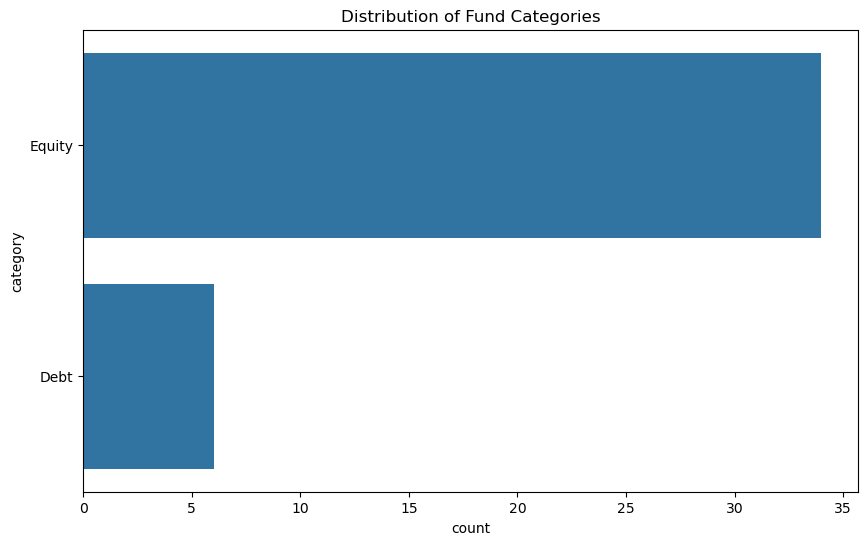

In [9]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=fund_master,
    y='category'
)

plt.title("Distribution of Fund Categories")

plt.show()

In [10]:
fund_master['risk_category'].value_counts()

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

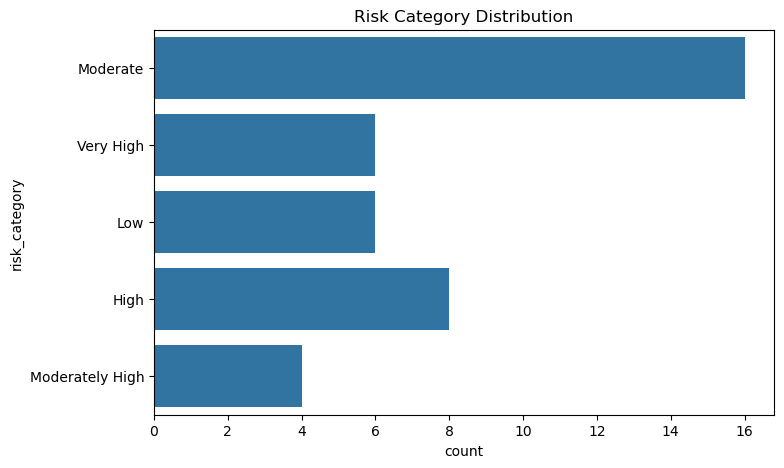

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    y='risk_category'
)

plt.title("Risk Category Distribution")
plt.show()

In [12]:
fund_master['fund_house'].value_counts()

fund_house
SBI Mutual Fund             5
HDFC Mutual Fund            5
ICICI Prudential MF         5
Nippon India MF             5
Kotak Mahindra MF           4
Axis Mutual Fund            4
Aditya Birla Sun Life MF    3
UTI Mutual Fund             3
Mirae Asset MF              3
DSP Mutual Fund             3
Name: count, dtype: int64

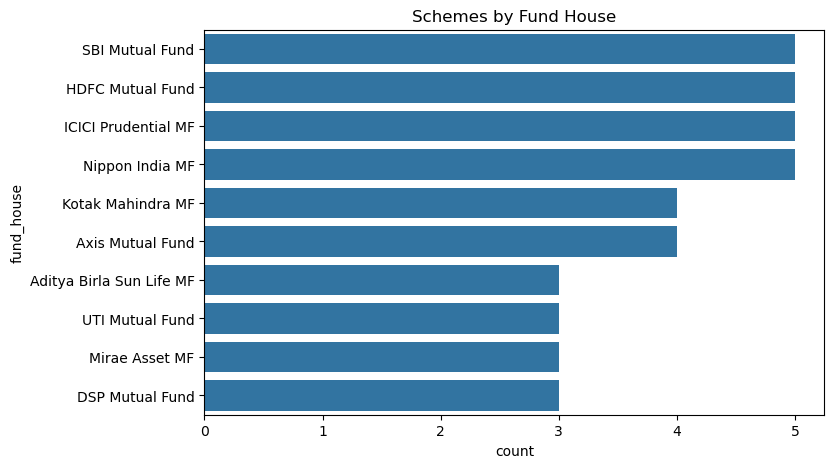

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    y='fund_house',
    order=fund_master['fund_house'].value_counts().index
)

plt.title("Schemes by Fund House")
plt.show()

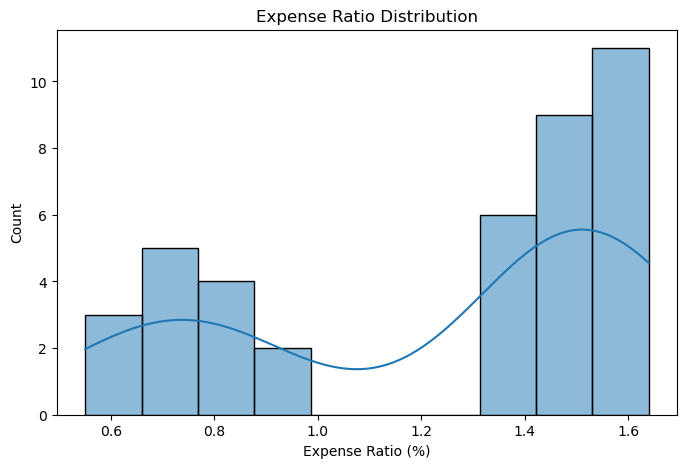

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    fund_master['expense_ratio_pct'],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.show()

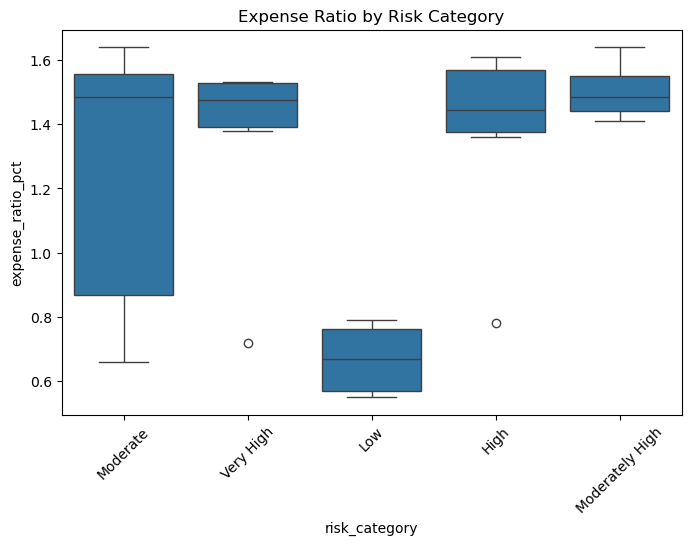

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=fund_master,
    x='risk_category',
    y='expense_ratio_pct'
)

plt.title("Expense Ratio by Risk Category")
plt.xticks(rotation=45)
plt.show()

In [17]:
fund_master.dtypes

amfi_code               int64
fund_house             object
scheme_name            object
category               object
sub_category           object
plan                   object
launch_date            object
benchmark              object
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager           object
risk_category          object
sebi_category_code     object
dtype: object

In [18]:
fund_master['launch_date'].dtype

dtype('O')

In [19]:
import pandas as pd

fund_master['launch_date'] = pd.to_datetime(
    fund_master['launch_date'],
    errors='coerce'
)

In [20]:
fund_master['launch_date'].dtype

dtype('<M8[ns]')

In [21]:
fund_master['launch_year'] = fund_master['launch_date'].dt.year

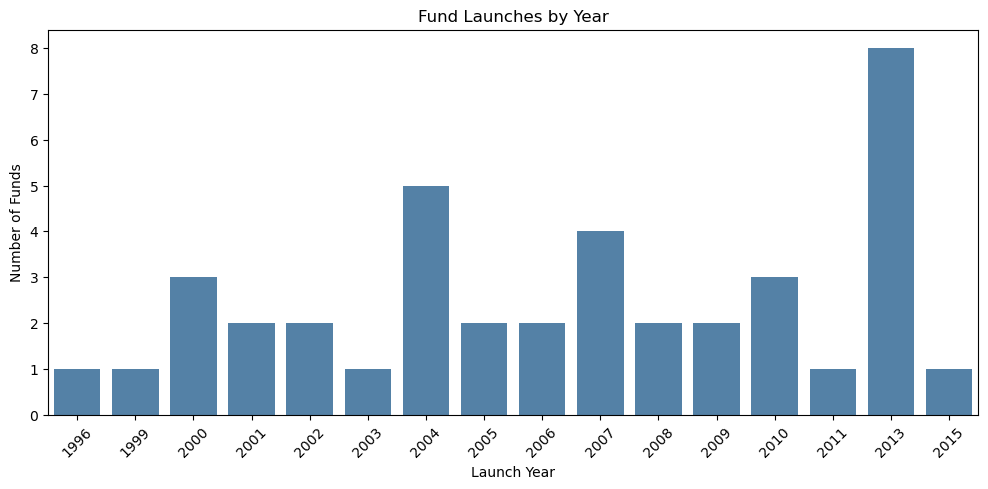

In [23]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=fund_master,
    x='launch_year',
    color='steelblue'
)

plt.xticks(rotation=45)
plt.xlabel("Launch Year")
plt.ylabel("Number of Funds")
plt.title("Fund Launches by Year")

plt.show()

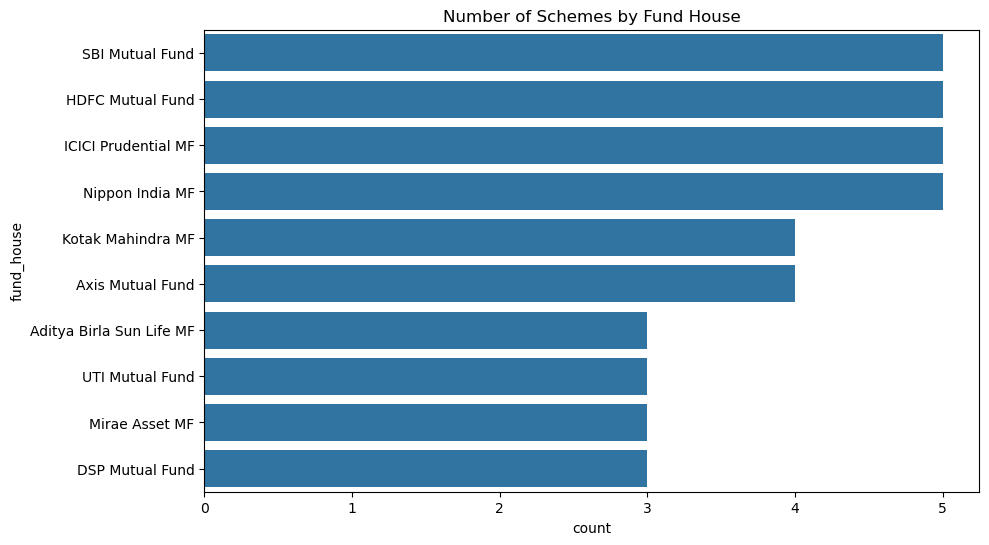

In [24]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=fund_master,
    y='fund_house',
    order=fund_master['fund_house'].value_counts().index
)

plt.title("Number of Schemes by Fund House")
plt.show()

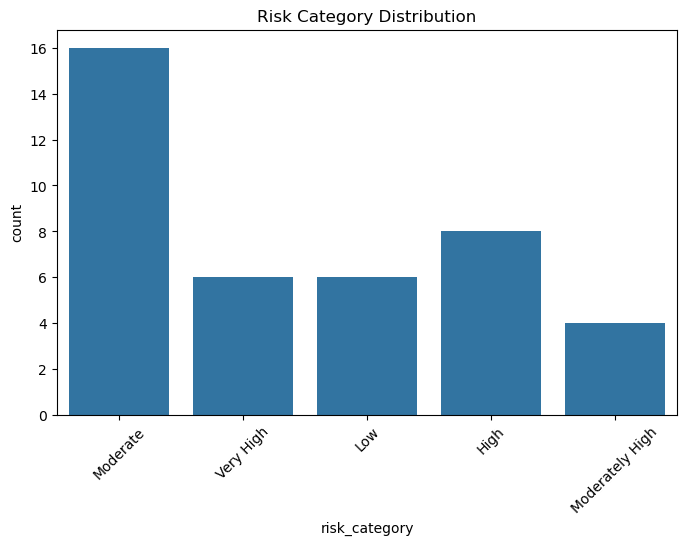

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    x='risk_category'
)

plt.xticks(rotation=45)
plt.title("Risk Category Distribution")
plt.show()

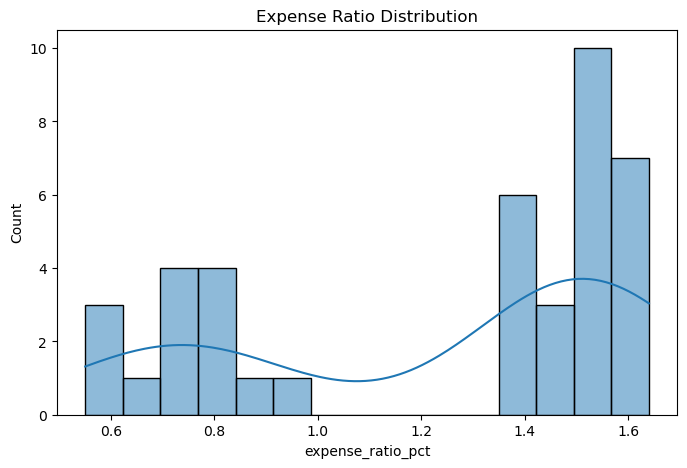

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    fund_master['expense_ratio_pct'],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.show()

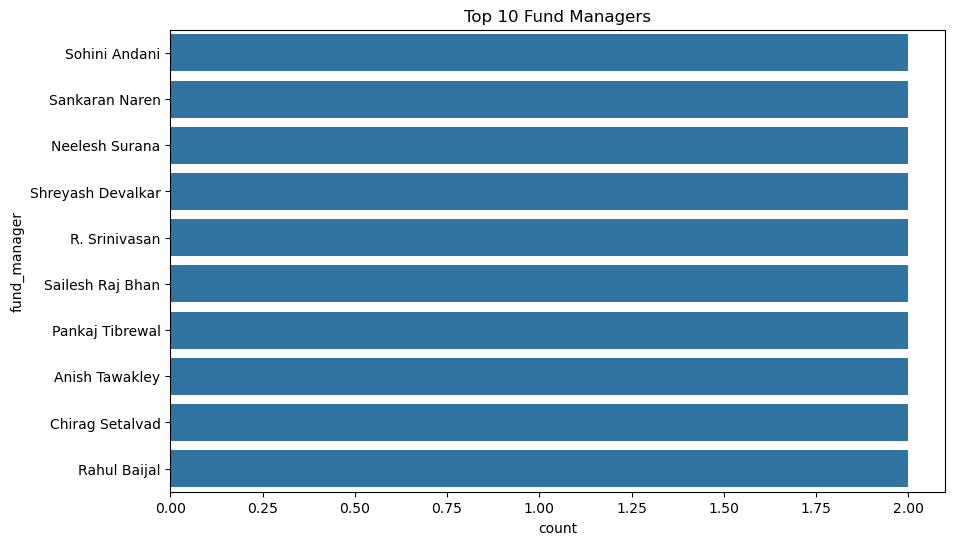

In [27]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=fund_master,
    y='fund_manager',
    order=fund_master['fund_manager'].value_counts().head(10).index
)

plt.title("Top 10 Fund Managers")
plt.show()

In [29]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [30]:
nav_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [31]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

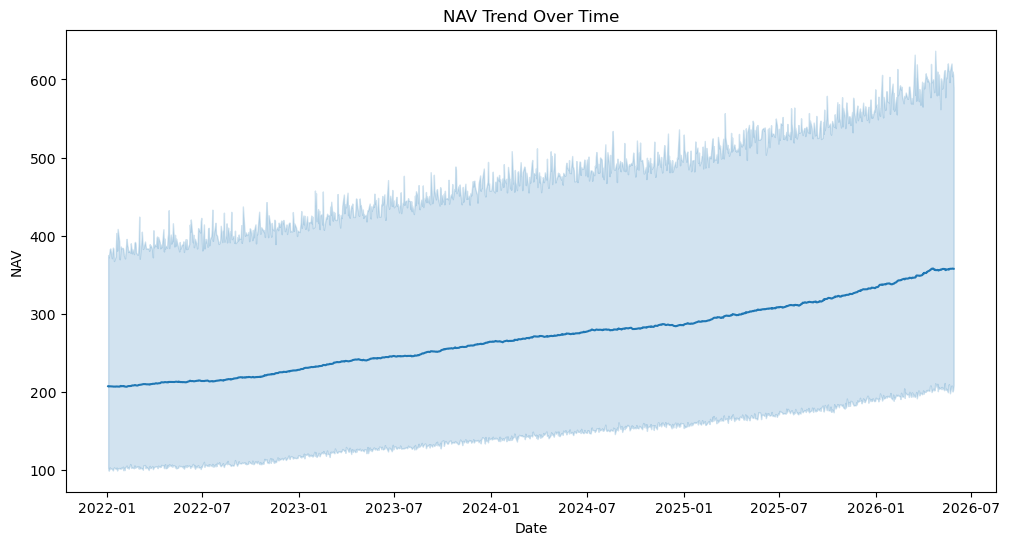

In [33]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=nav_history,
    x='date',
    y='nav'
)

plt.title("NAV Trend Over Time")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()


In [34]:
nav_history.groupby('amfi_code')['nav'].mean().sort_values(ascending=False)

amfi_code
120844    3705.876331
125497     797.454477
100016     566.191221
149322     439.176645
101206     435.975472
101208     358.390923
120841     355.078750
120507     334.083952
120505     283.999240
120506     274.320937
102887     249.530563
118635     228.253463
100033     190.825330
119598     180.314069
149323     151.492094
149324     148.214974
148568     147.760011
125498     138.214296
102886     137.102766
148567     136.480609
102885     128.493803
119094     121.444471
119599     108.581372
118634     102.897924
119552     100.745458
120504      99.940254
120843      97.822895
120503      89.681075
119551      78.847733
119095      75.647006
118632      73.629655
120842      67.662844
118633      62.118409
101207      58.956796
148569      54.523904
119120      48.570406
119092      48.021952
119093      43.771809
118636      33.616353
100025      29.100359
Name: nav, dtype: float64

In [35]:
nav_history.groupby('amfi_code')['nav'].mean()\
.sort_values(ascending=False)\
.head(10)

amfi_code
120844    3705.876331
125497     797.454477
100016     566.191221
149322     439.176645
101206     435.975472
101208     358.390923
120841     355.078750
120507     334.083952
120505     283.999240
120506     274.320937
Name: nav, dtype: float64

In [36]:
nav_history.groupby('amfi_code')['nav'].max()\
.sort_values(ascending=False)\
.head(10)

amfi_code
120844    4268.5497
125497    1286.0621
101206     808.0982
100016     669.7236
149322     658.5042
120841     484.6292
120505     476.3696
102887     419.3008
120506     410.2909
101208     410.1021
Name: nav, dtype: float64

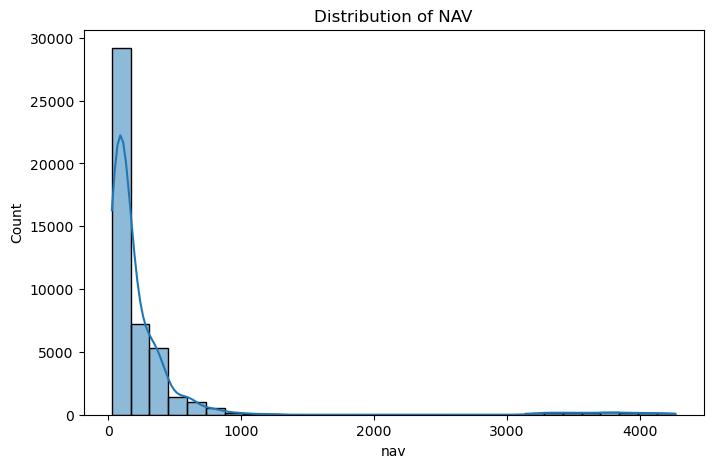

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    nav_history['nav'],
    bins=30,
    kde=True
)

plt.title("Distribution of NAV")
plt.show()

In [38]:
nav_history['month'] = nav_history['date'].dt.to_period('M')

In [39]:
monthly_nav = nav_history.groupby('month')['nav'].mean().reset_index()

monthly_nav['month'] = monthly_nav['month'].astype(str)

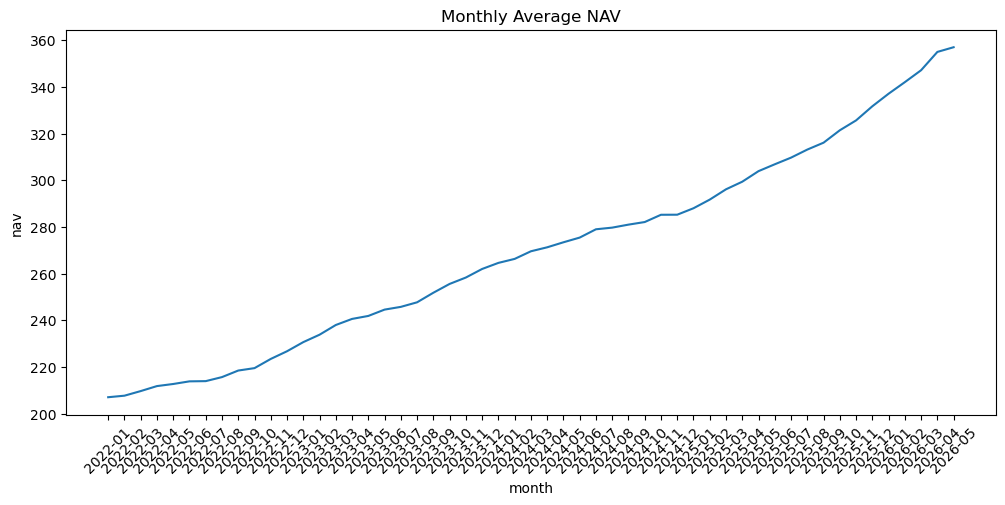

In [40]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_nav,
    x='month',
    y='nav'
)

plt.xticks(rotation=45)
plt.title("Monthly Average NAV")
plt.show()

In [41]:
top_aum = (
    aum_fund_house
    .groupby('fund_house')['aum_lakh_crore']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_aum.values,
    y=top_aum.index
)

plt.xlabel("Average AUM (Lakh Crore)")
plt.ylabel("Fund House")
plt.title("Top 10 Fund Houses by Average AUM")

plt.show()

NameError: name 'aum_fund_house' is not defined

In [43]:
import pandas as pd

aum_fund_house = pd.read_csv(
    r"C:\Users\swapnil\Mutual Fund Analytics\data\raw\processed\03_aum_by_fund_house_clean.csv"
)

aum_fund_house.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [44]:
aum_fund_house['date'] = pd.to_datetime(aum_fund_house['date'])

In [45]:
aum_fund_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[ns]
 1   fund_house      90 non-null     object        
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 3.6+ KB


In [46]:
query = "SELECT * FROM aum_fund_house"

aum_fund_house = pd.read_sql(query, engine)

aum_fund_house.head()

NameError: name 'engine' is not defined

In [47]:
import pandas as pd
from sqlalchemy import create_engine


In [137]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="swapnil@123",
    host="127.0.0.1",
    port=5432,
    database="bluestock_mf"
)

engine = create_engine(url)

In [138]:
connection = engine.connect()

print("Connected Successfully!")

connection.close()

Connected Successfully!


In [52]:
query = "SELECT * FROM aum_fund_house"

aum_fund_house = pd.read_sql(query, engine)

aum_fund_house.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [53]:
query = "SELECT * FROM aum_fund_house"

aum_fund_house = pd.read_sql(query, engine)

aum_fund_house.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [54]:
aum_fund_house.shape

(90, 5)

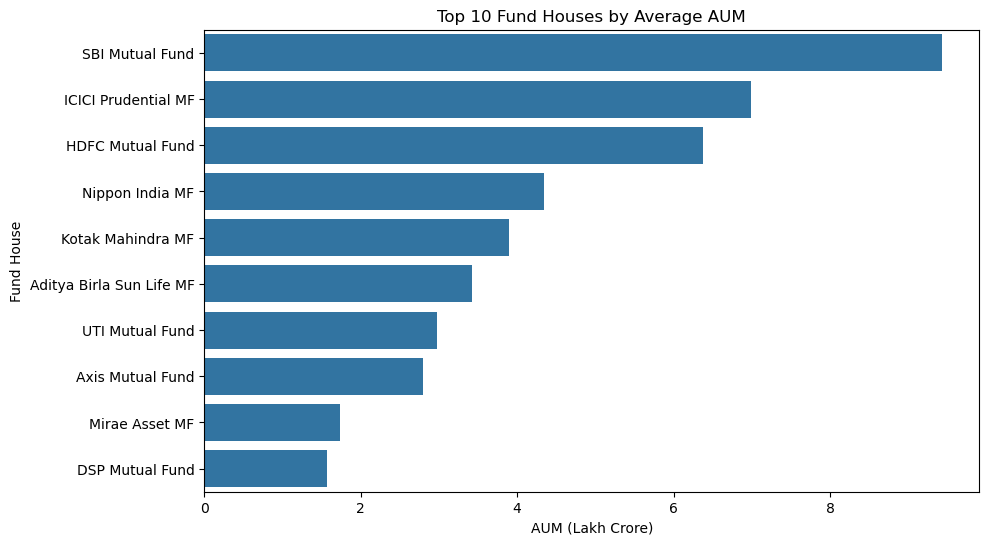

In [64]:
# Top 10 Fund Houses by Average AUM

top_aum = (
    aum_fund_house
    .groupby('fund_house')['aum_lakh_crore']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_aum.values,
    y=top_aum.index
)

plt.title("Top 10 Fund Houses by Average AUM")
plt.xlabel("AUM (Lakh Crore)")
plt.ylabel("Fund House")

plt.show()

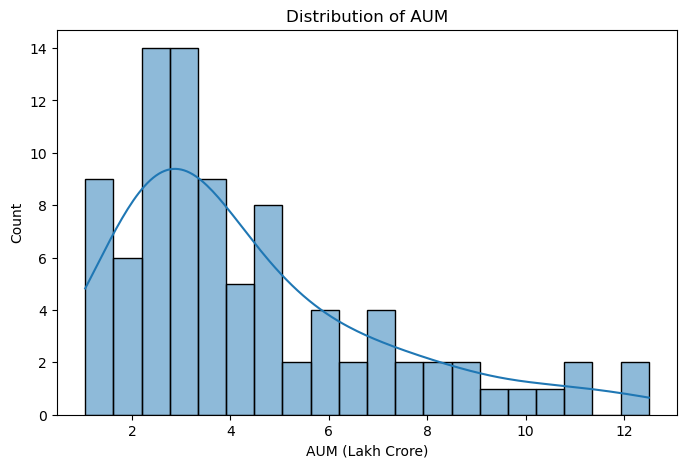

In [65]:
#AUM Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    aum_fund_house['aum_lakh_crore'],
    bins=20,
    kde=True
)

plt.title("Distribution of AUM")
plt.xlabel("AUM (Lakh Crore)")
plt.show()

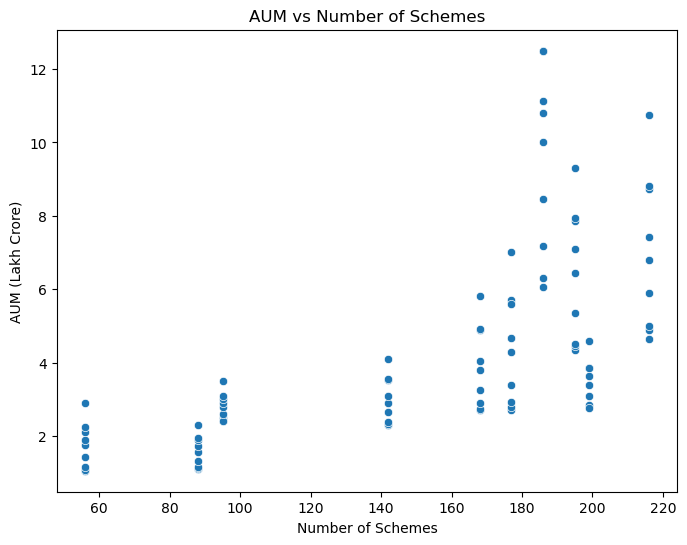

In [66]:
#AUM vs Number of Schemes

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=aum_fund_house,
    x='num_schemes',
    y='aum_lakh_crore'
)

plt.title("AUM vs Number of Schemes")
plt.xlabel("Number of Schemes")
plt.ylabel("AUM (Lakh Crore)")

plt.show()

In [67]:
aum_fund_house['date'] = pd.to_datetime(aum_fund_house['date'])

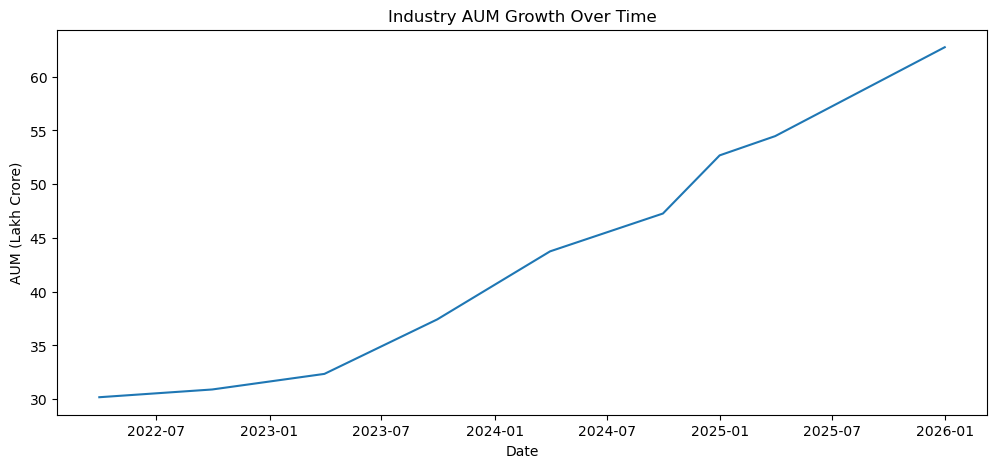

In [69]:
#Industry AUM Growth Over Time

monthly_aum = (
    aum_fund_house
    .groupby('date')['aum_lakh_crore']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_aum,
    x='date',
    y='aum_lakh_crore'
)

plt.title("Industry AUM Growth Over Time")
plt.xlabel("Date")
plt.ylabel("AUM (Lakh Crore)")

plt.show()

In [72]:
query = "SELECT * FROM monthly_sip"

monthly_sip = pd.read_sql(query, engine)

monthly_sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,31.456944
1,2022-02-01,11438,4.93,8.20,4.85,31.456944
2,2022-03-01,12328,5.09,10.50,5.01,31.456944
3,2022-04-01,11863,5.48,9.52,5.12,31.456944
4,2022-05-01,12286,5.55,8.10,5.15,31.456944


In [73]:
monthly_sip['month'] = pd.to_datetime(monthly_sip['month'])

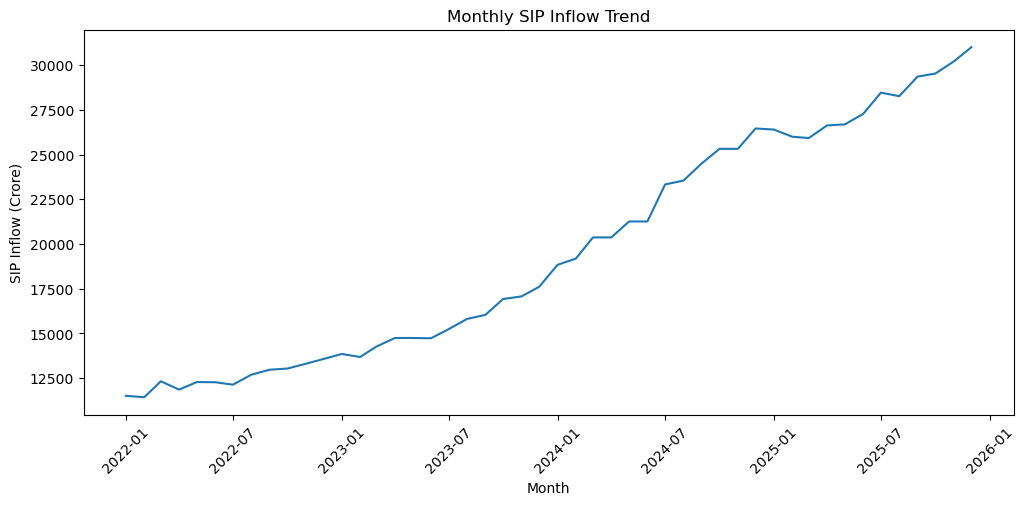

In [74]:
#Monthly SIP Inflow Trend

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_sip,
    x='month',
    y='sip_inflow_crore'
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore)')
plt.title('Monthly SIP Inflow Trend')

plt.show()

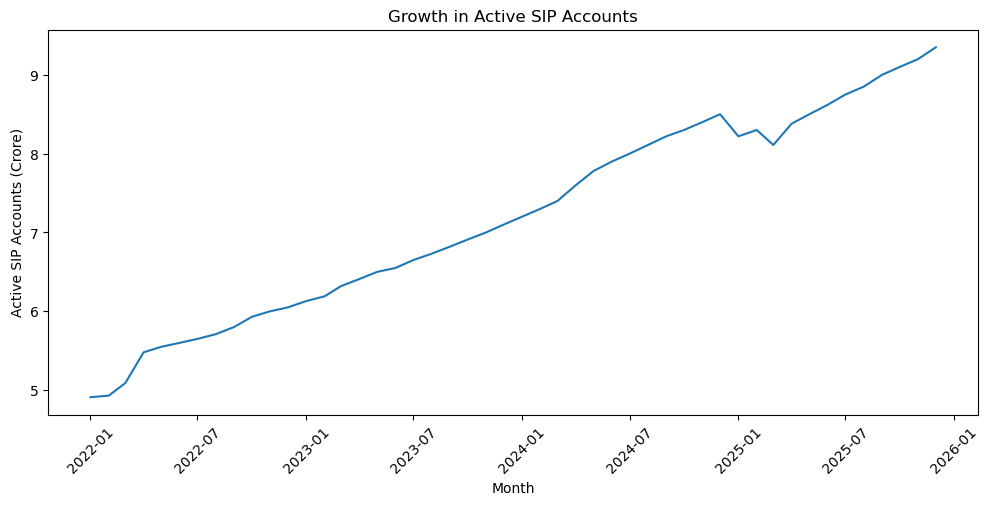

In [76]:
#Active SIP Accounts Trend

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_sip,
    x='month',
    y='active_sip_accounts_crore'
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Active SIP Accounts (Crore)')
plt.title('Growth in Active SIP Accounts')

plt.show()

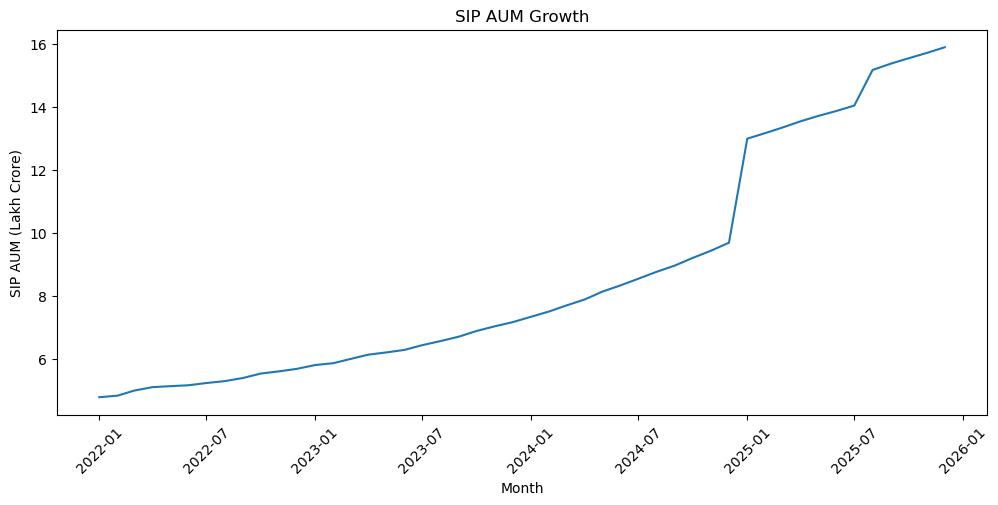

In [77]:
#SIP AUM Trend

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_sip,
    x='month',
    y='sip_aum_lakh_crore'
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('SIP AUM (Lakh Crore)')
plt.title('SIP AUM Growth')

plt.show()

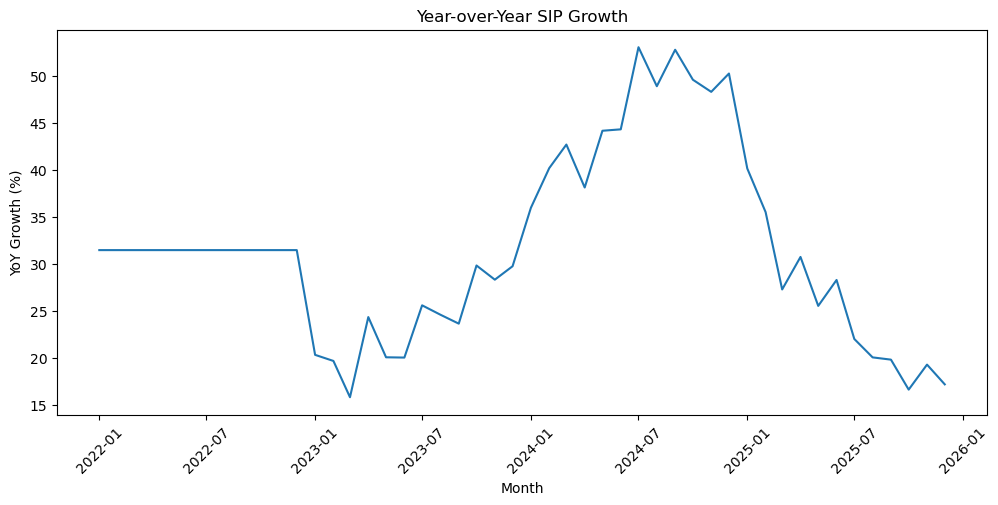

In [78]:
#YoY Growth Percentage Trend

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_sip,
    x='month',
    y='yoy_growth_pct'
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('YoY Growth (%)')
plt.title('Year-over-Year SIP Growth')

plt.show()

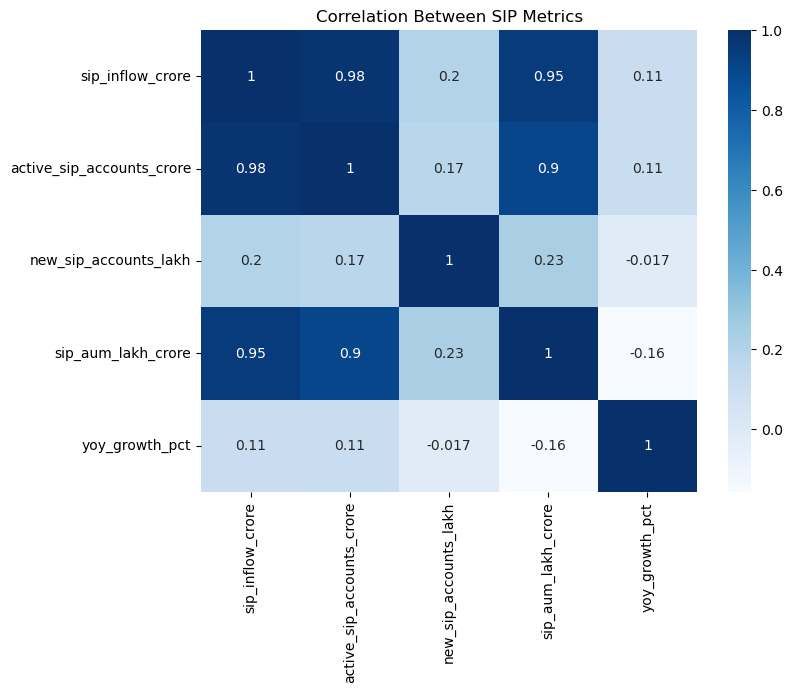

In [79]:
#Correlation Between SIP Metrics

plt.figure(figsize=(8,6))

sns.heatmap(
    monthly_sip.select_dtypes(include='number').corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Between SIP Metrics')

plt.show()

In [80]:
query = "SELECT * FROM category_inflows"

category_inflows = pd.read_sql(query, engine)

category_inflows.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [81]:
category_inflows['month'] = pd.to_datetime(category_inflows['month'])

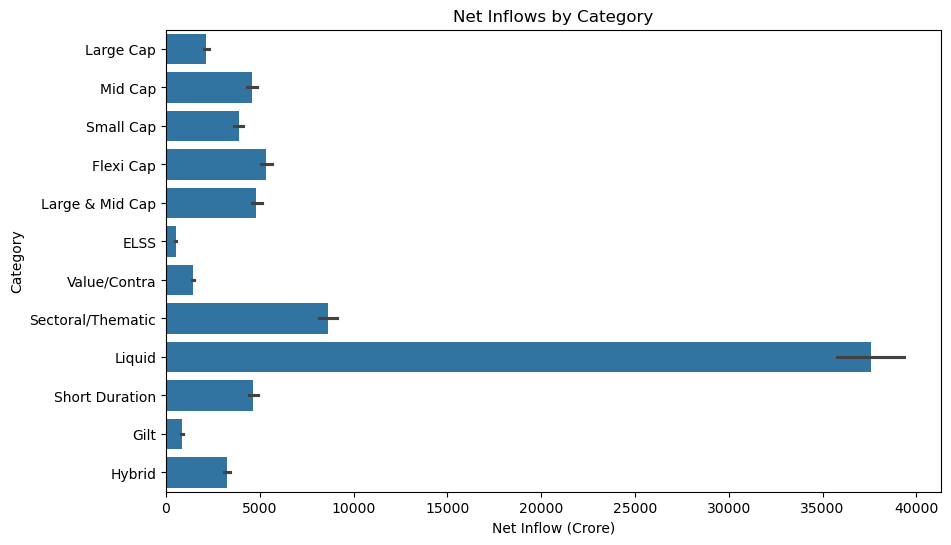

In [82]:
#Net Inflows by Category

plt.figure(figsize=(10,6))

sns.barplot(
    data=category_inflows,
    x='net_inflow_crore',
    y='category'
)

plt.xlabel('Net Inflow (Crore)')
plt.ylabel('Category')
plt.title('Net Inflows by Category')

plt.show()

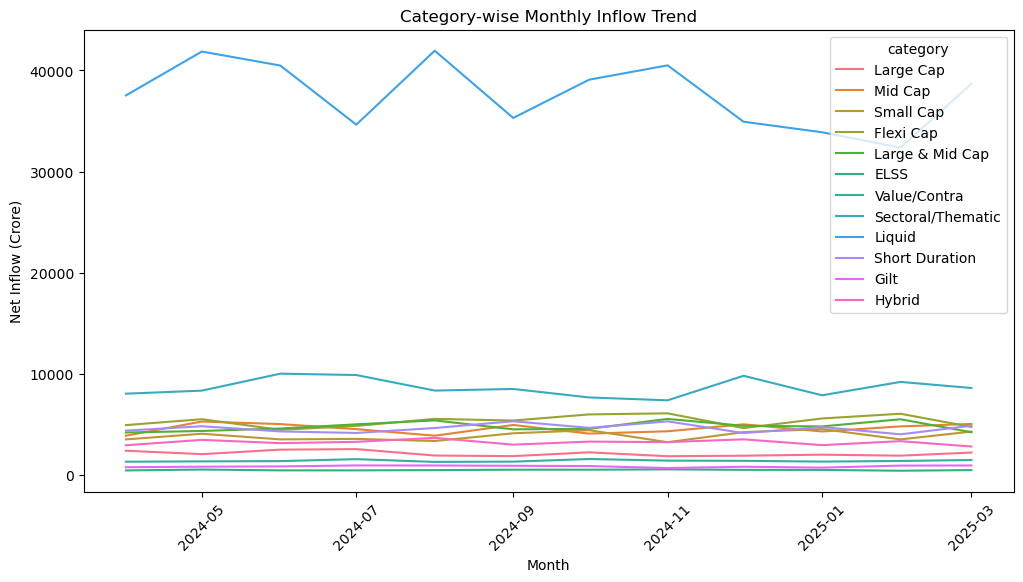

In [83]:
#Monthly Category-wise Inflow Trend

plt.figure(figsize=(12,6))

sns.lineplot(
    data=category_inflows,
    x='month',
    y='net_inflow_crore',
    hue='category'
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Net Inflow (Crore)')
plt.title('Category-wise Monthly Inflow Trend')

plt.show()

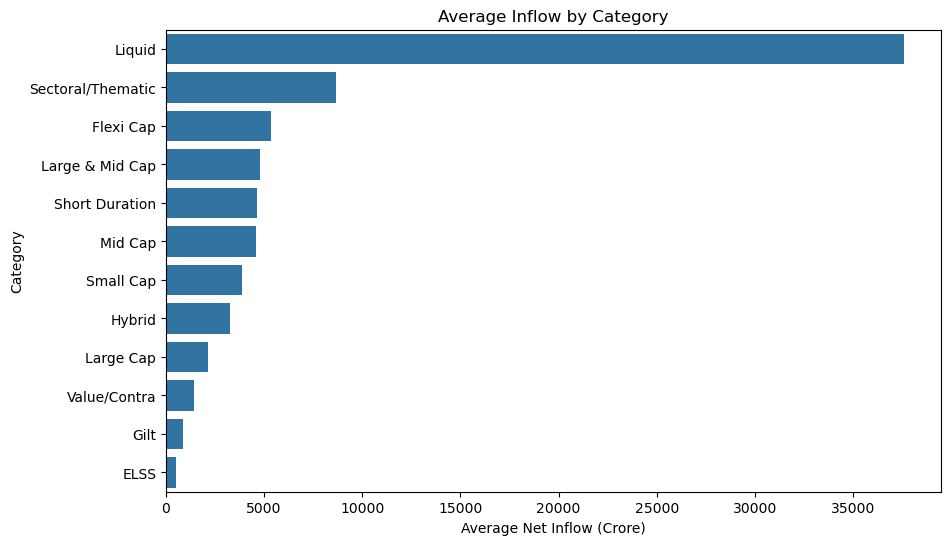

In [84]:
#Average Inflow by Category

avg_inflow = (
    category_inflows
    .groupby('category')['net_inflow_crore']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_inflow.values,
    y=avg_inflow.index
)

plt.xlabel('Average Net Inflow (Crore)')
plt.ylabel('Category')
plt.title('Average Inflow by Category')

plt.show()

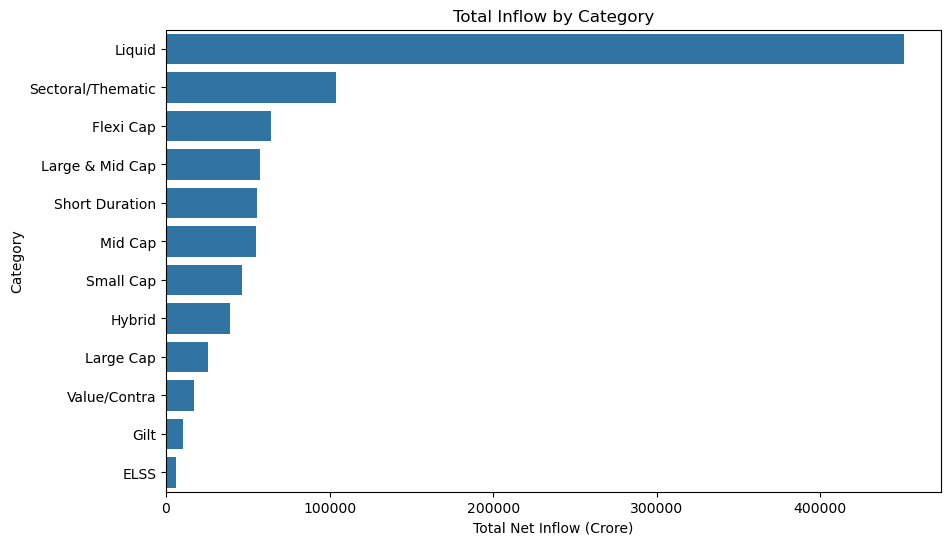

In [85]:
#Total Inflow by Category

total_inflow = (
    category_inflows
    .groupby('category')['net_inflow_crore']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=total_inflow.values,
    y=total_inflow.index
)

plt.xlabel('Total Net Inflow (Crore)')
plt.ylabel('Category')
plt.title('Total Inflow by Category')

plt.show()

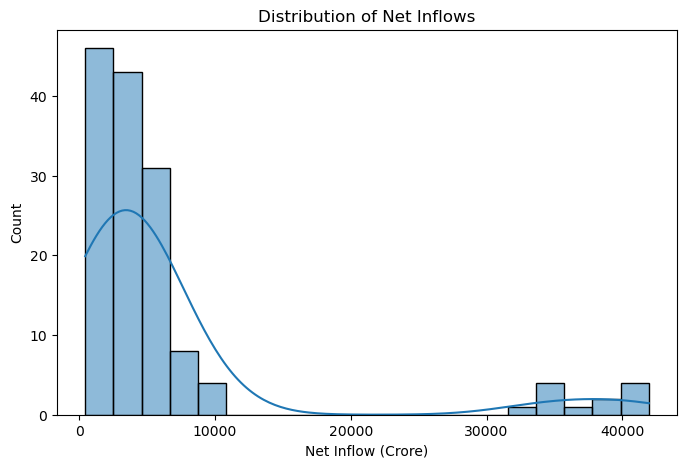

In [86]:
#Distribution of Net Inflows

plt.figure(figsize=(8,5))

sns.histplot(
    category_inflows['net_inflow_crore'],
    bins=20,
    kde=True
)

plt.xlabel('Net Inflow (Crore)')
plt.title('Distribution of Net Inflows')

plt.show()

In [87]:
query = "SELECT * FROM industry_folio"

industry_folio = pd.read_sql(query, engine)

industry_folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [88]:
industry_folio['month'] = pd.to_datetime(industry_folio['month'])

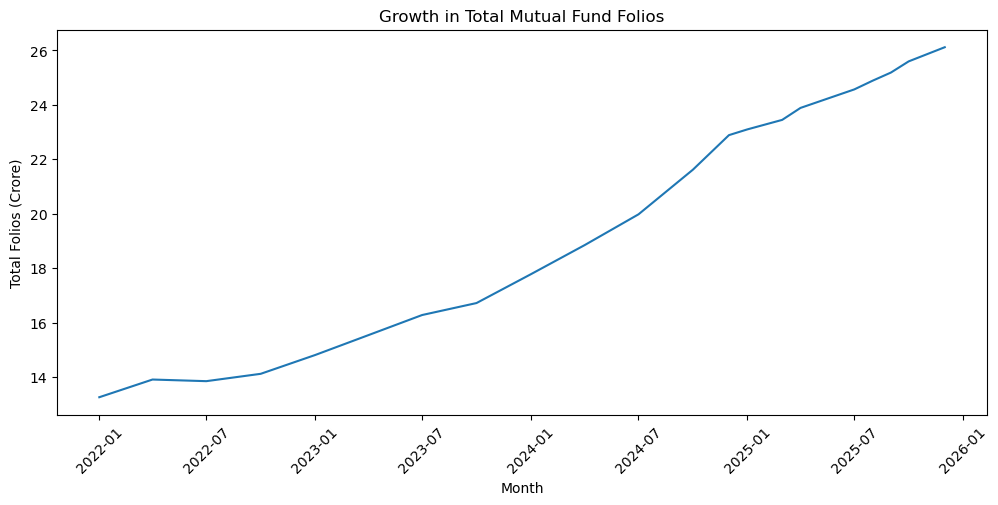

In [89]:
#Total Folios Trend

plt.figure(figsize=(12,5))

sns.lineplot(
    data=industry_folio,
    x='month',
    y='total_folios_crore'
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
plt.title('Growth in Total Mutual Fund Folios')

plt.show()

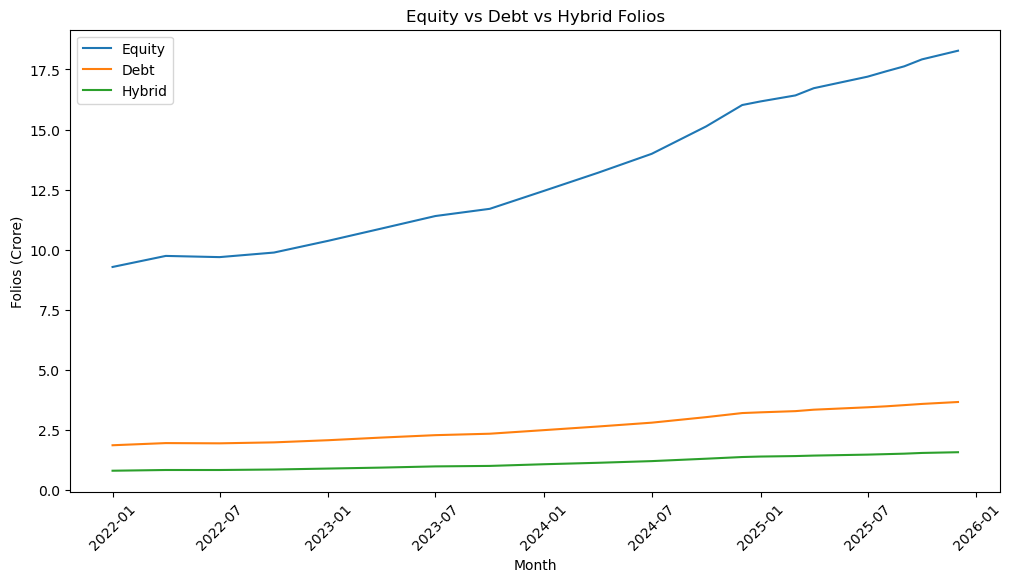

In [90]:
#Equity, Debt and Hybrid Folios Trend

plt.figure(figsize=(12,6))

sns.lineplot(
    data=industry_folio,
    x='month',
    y='equity_folios_crore',
    label='Equity'
)

sns.lineplot(
    data=industry_folio,
    x='month',
    y='debt_folios_crore',
    label='Debt'
)

sns.lineplot(
    data=industry_folio,
    x='month',
    y='hybrid_folios_crore',
    label='Hybrid'
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Folios (Crore)')
plt.title('Equity vs Debt vs Hybrid Folios')

plt.show()

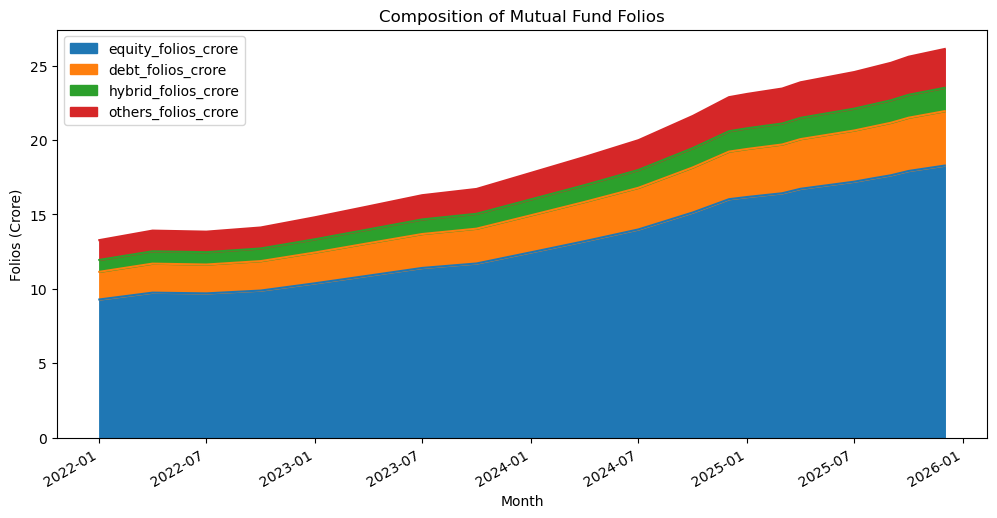

In [92]:
#Area Plot of Folios

industry_folio.set_index('month')[
    [
        'equity_folios_crore',
        'debt_folios_crore',
        'hybrid_folios_crore',
        'others_folios_crore'
    ]
].plot(
    kind='area',
    figsize=(12,6),
    stacked=True
)

plt.xlabel('Month')
plt.ylabel('Folios (Crore)')
plt.title('Composition of Mutual Fund Folios')

plt.show()

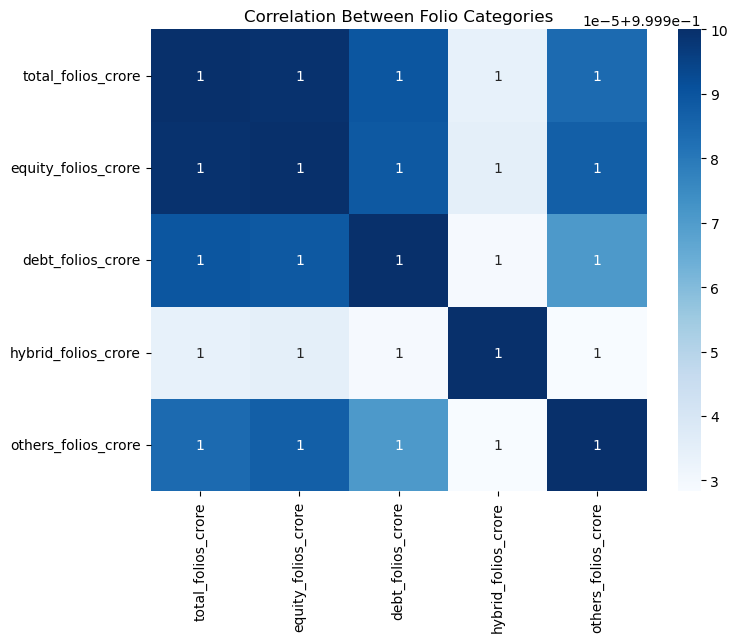

In [93]:
#Correlation Between Folio Types'

plt.figure(figsize=(8,6))

sns.heatmap(
    industry_folio.select_dtypes(include='number').corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Between Folio Categories')

plt.show()

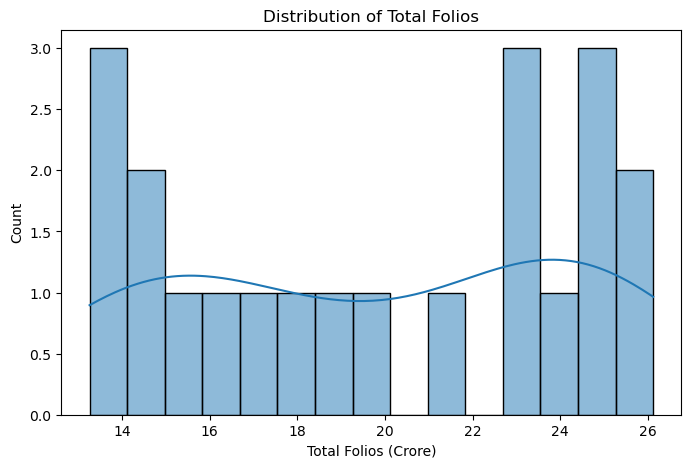

In [94]:
#Distribution of Total Folios

plt.figure(figsize=(8,5))

sns.histplot(
    industry_folio['total_folios_crore'],
    bins=15,
    kde=True
)

plt.xlabel('Total Folios (Crore)')
plt.title('Distribution of Total Folios')

plt.show()

In [95]:
query = "SELECT * FROM scheme_performance"

scheme_performance = pd.read_sql(query, engine)

scheme_performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


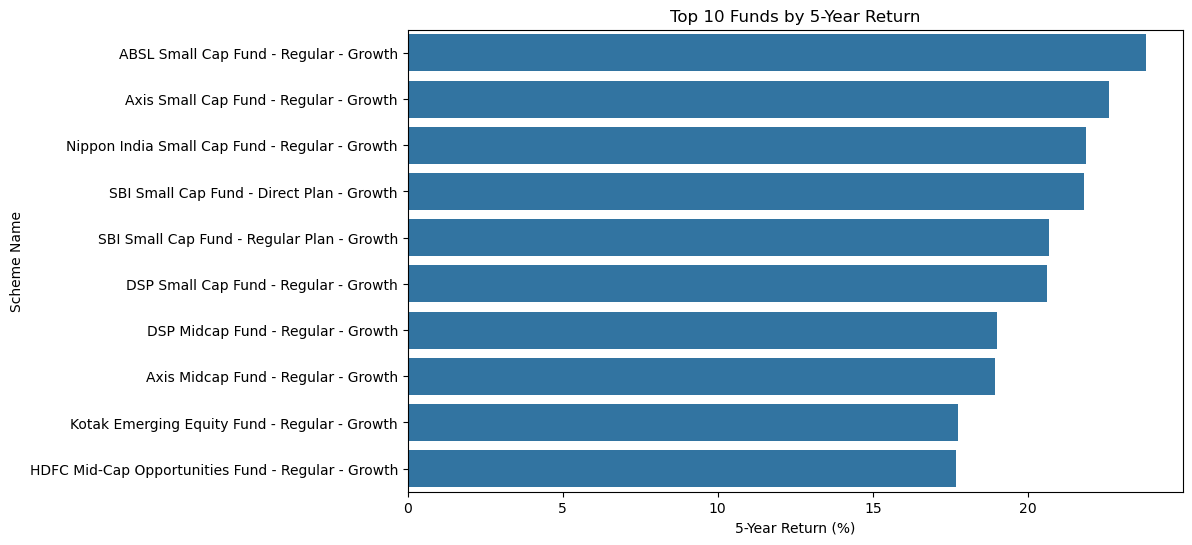

In [96]:
#Top 10 Funds by 5-Year Return

top_5yr = (
    scheme_performance
    .sort_values('return_5yr_pct', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_5yr,
    x='return_5yr_pct',
    y='scheme_name'
)

plt.xlabel('5-Year Return (%)')
plt.ylabel('Scheme Name')
plt.title('Top 10 Funds by 5-Year Return')

plt.show()

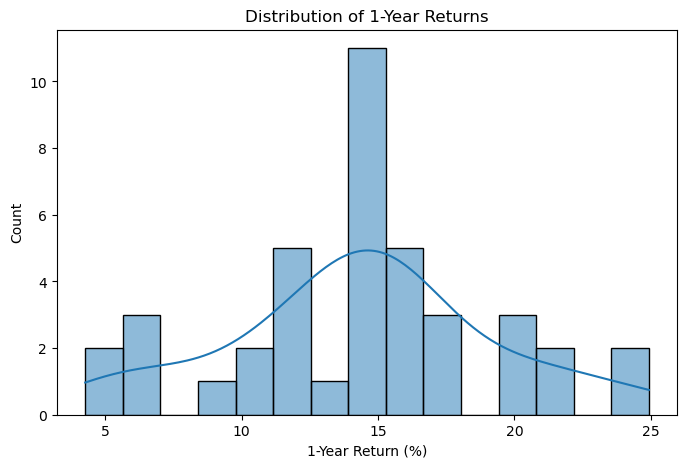

In [97]:
#Distribution of 1-Year Returns

plt.figure(figsize=(8,5))

sns.histplot(
    scheme_performance['return_1yr_pct'],
    bins=15,
    kde=True
)

plt.xlabel('1-Year Return (%)')
plt.title('Distribution of 1-Year Returns')

plt.show()

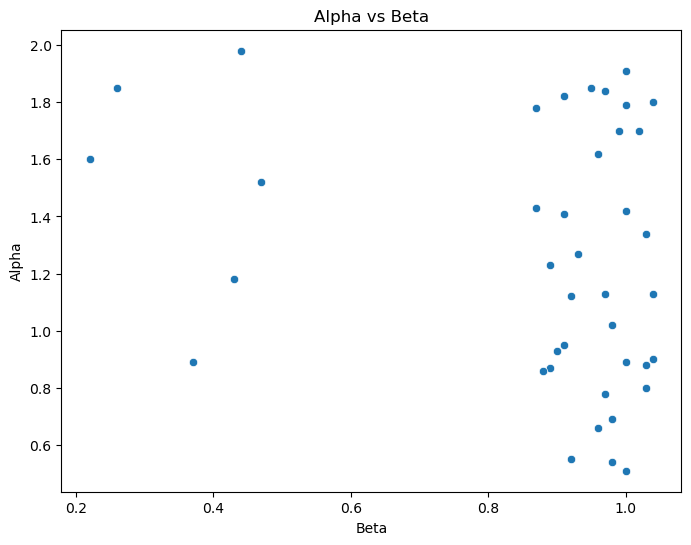

In [98]:
#Alpha vs Beta

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=scheme_performance,
    x='beta',
    y='alpha'
)

plt.xlabel('Beta')
plt.ylabel('Alpha')
plt.title('Alpha vs Beta')

plt.show()

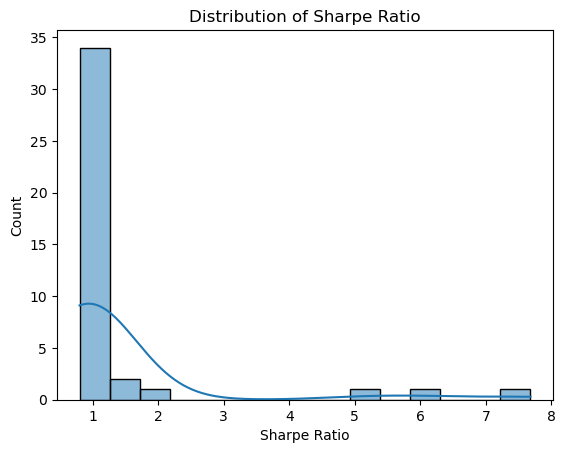

In [99]:
#Sharpe Ratio Distributioplt.figure(figsize=(8,5))

sns.histplot(
    scheme_performance['sharpe_ratio'],
    bins=15,
    kde=True
)

plt.xlabel('Sharpe Ratio')
plt.title('Distribution of Sharpe Ratio')

plt.show()

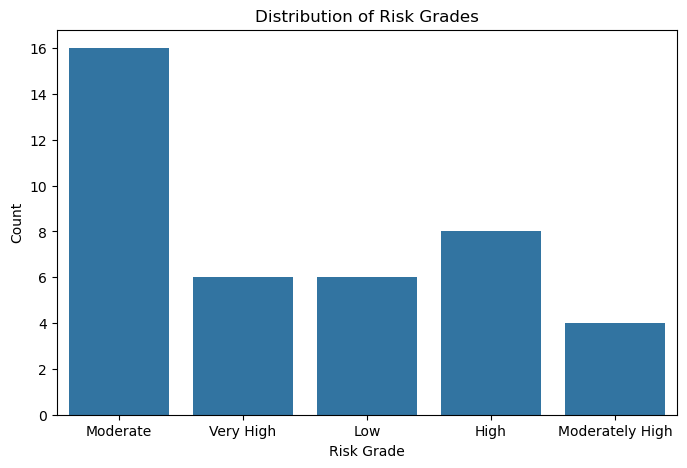

In [100]:
#Risk Grade Count

plt.figure(figsize=(8,5))

sns.countplot(
    data=scheme_performance,
    x='risk_grade'
)

plt.xlabel('Risk Grade')
plt.ylabel('Count')
plt.title('Distribution of Risk Grades')

plt.show()

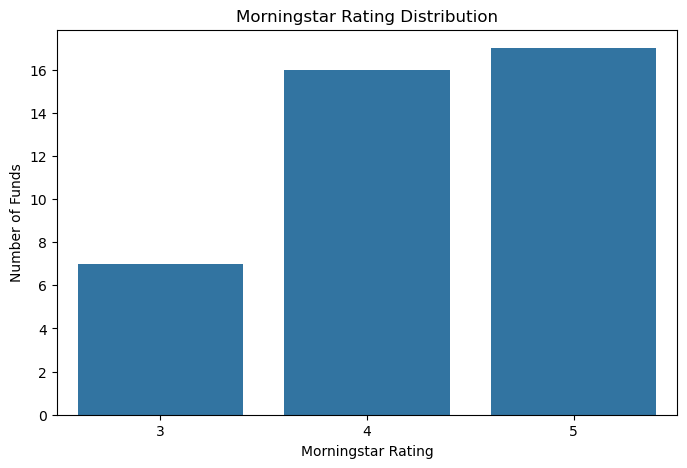

In [101]:
#Morningstar Rating Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=scheme_performance,
    x='morningstar_rating'
)

plt.xlabel('Morningstar Rating')
plt.ylabel('Number of Funds')
plt.title('Morningstar Rating Distribution')

plt.show()

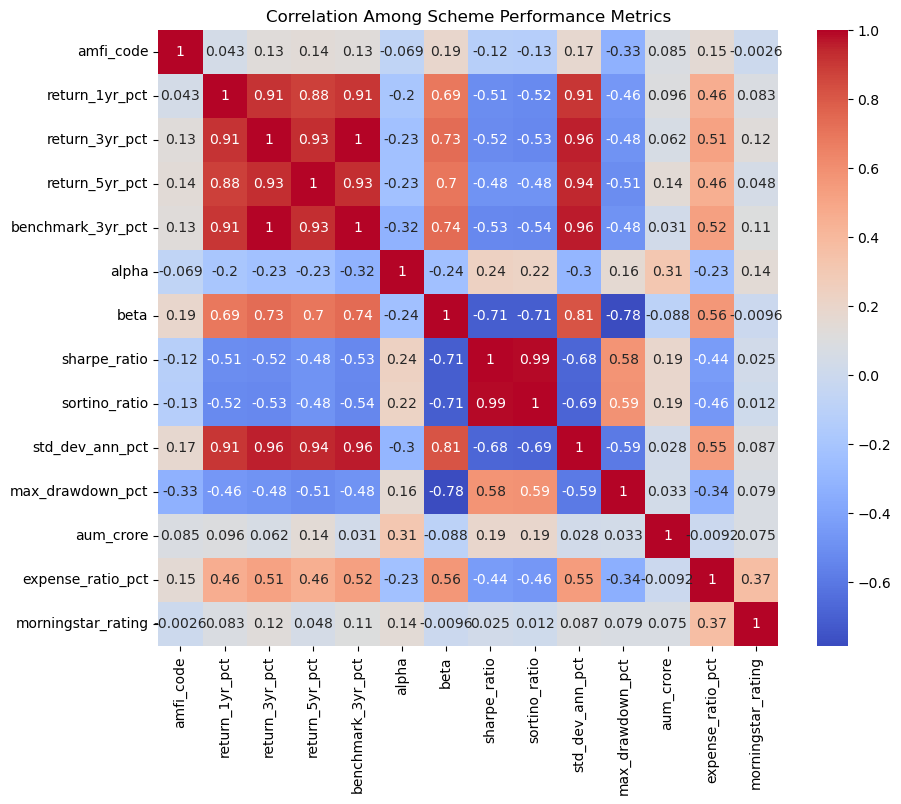

In [102]:
#Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    scheme_performance.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Among Scheme Performance Metrics')

plt.show()

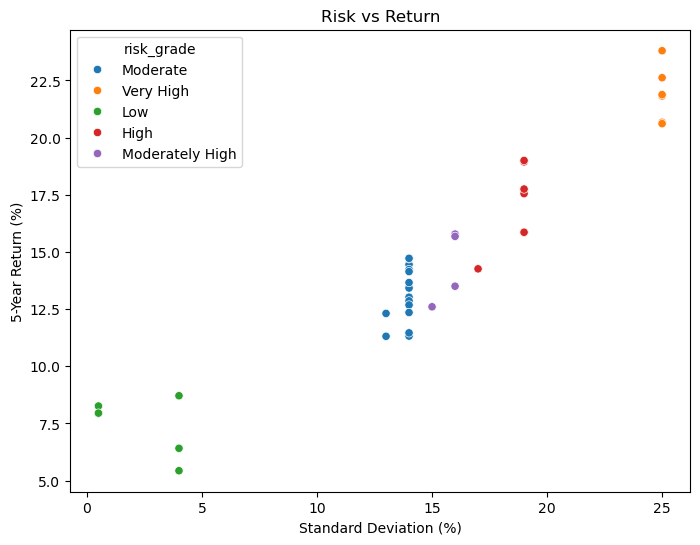

In [103]:
#Risk vs Return

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=scheme_performance,
    x='std_dev_ann_pct',
    y='return_5yr_pct',
    hue='risk_grade'
)

plt.xlabel('Standard Deviation (%)')
plt.ylabel('5-Year Return (%)')
plt.title('Risk vs Return')

plt.show()

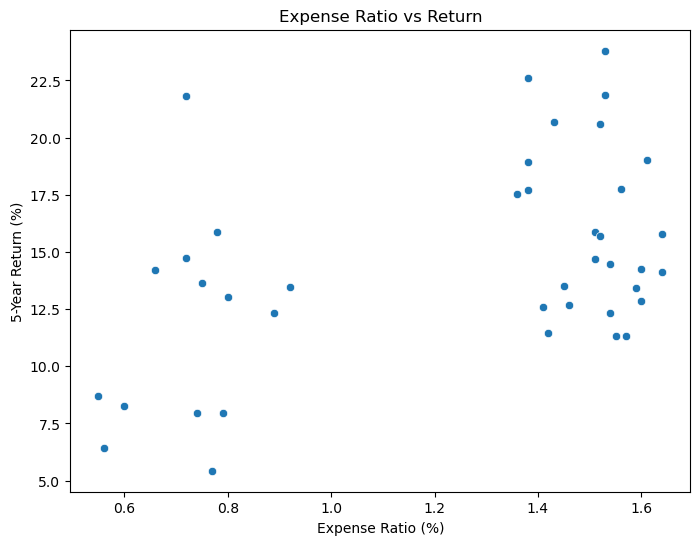

In [104]:
#Expense Ratio vs Return

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=scheme_performance,
    x='expense_ratio_pct',
    y='return_5yr_pct'
)

plt.xlabel('Expense Ratio (%)')
plt.ylabel('5-Year Return (%)')
plt.title('Expense Ratio vs Return')

plt.show()

In [106]:
query = "SELECT * FROM investor_transactions"

investor_transactions = pd.read_sql(query, engine)

investor_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [107]:
investor_transactions['transaction_date'] = pd.to_datetime(
    investor_transactions['transaction_date']
)

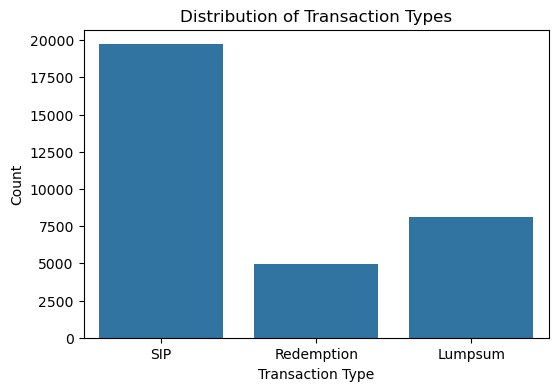

In [108]:
#Transaction Type Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=investor_transactions,
    x='transaction_type'
)

plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types')

plt.show()

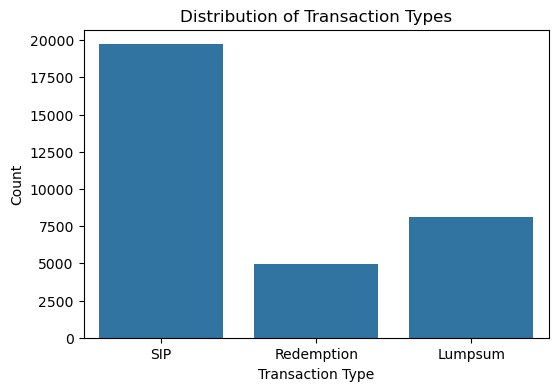

In [109]:
#Transaction Type Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=investor_transactions,
    x='transaction_type'
)

plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types')

plt.show()

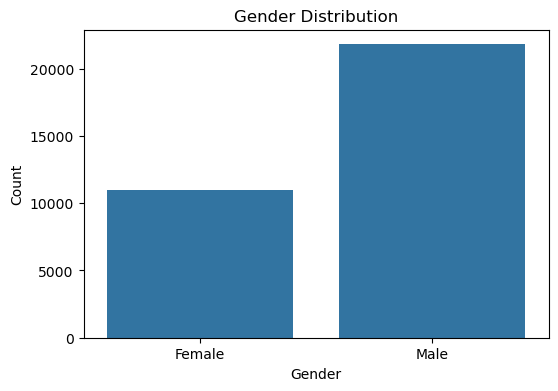

In [110]:
#Gender-wise Transactions

plt.figure(figsize=(6,4))

sns.countplot(
    data=investor_transactions,
    x='gender'
)

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')

plt.show()

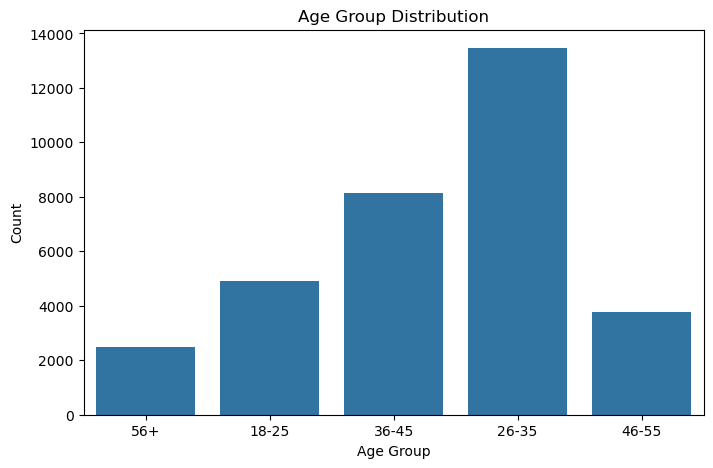

In [111]:
#Age Group Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=investor_transactions,
    x='age_group'
)

plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Age Group Distribution')

plt.show()

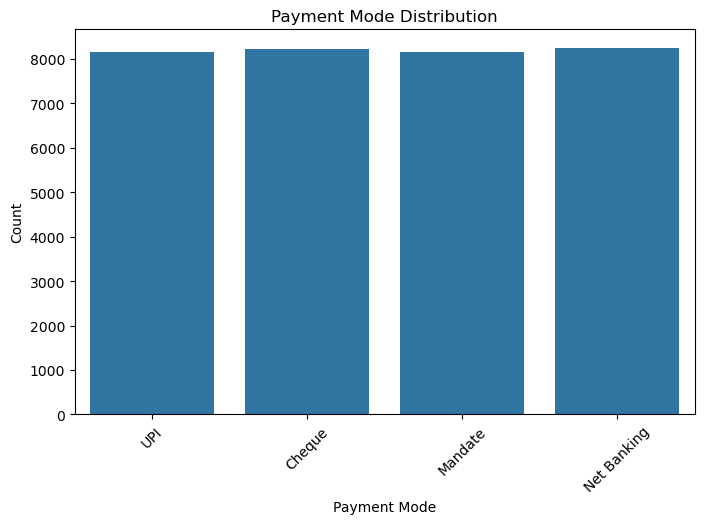

In [112]:
#Payment Mode Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=investor_transactions,
    x='payment_mode'
)

plt.xlabel('Payment Mode')
plt.ylabel('Count')
plt.title('Payment Mode Distribution')

plt.xticks(rotation=45)

plt.show()

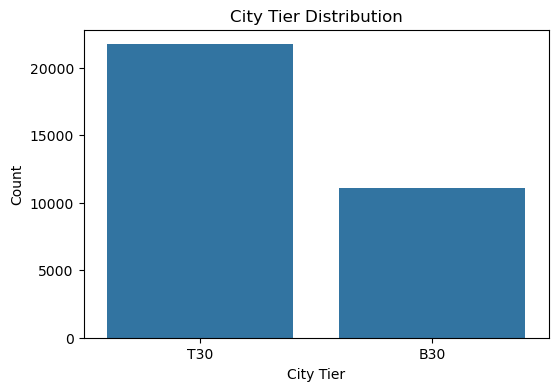

In [113]:
#City Tier Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=investor_transactions,
    x='city_tier'
)

plt.xlabel('City Tier')
plt.ylabel('Count')
plt.title('City Tier Distribution')

plt.show()

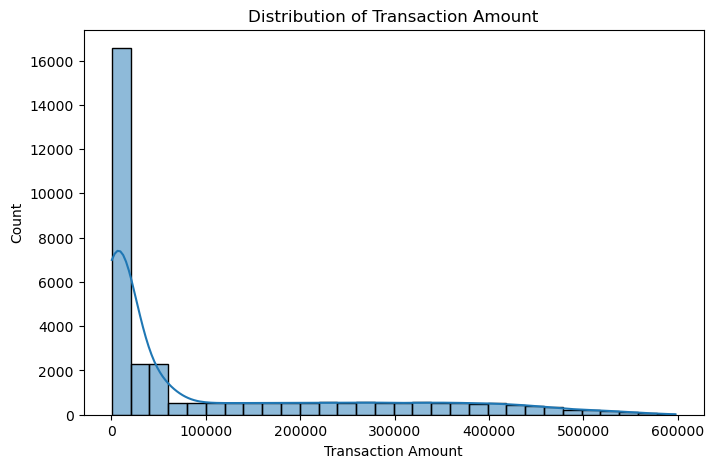

In [114]:
#Transaction Amount Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    investor_transactions['amount_inr'],
    bins=30,
    kde=True
)

plt.xlabel('Transaction Amount')
plt.title('Distribution of Transaction Amount')

plt.show()

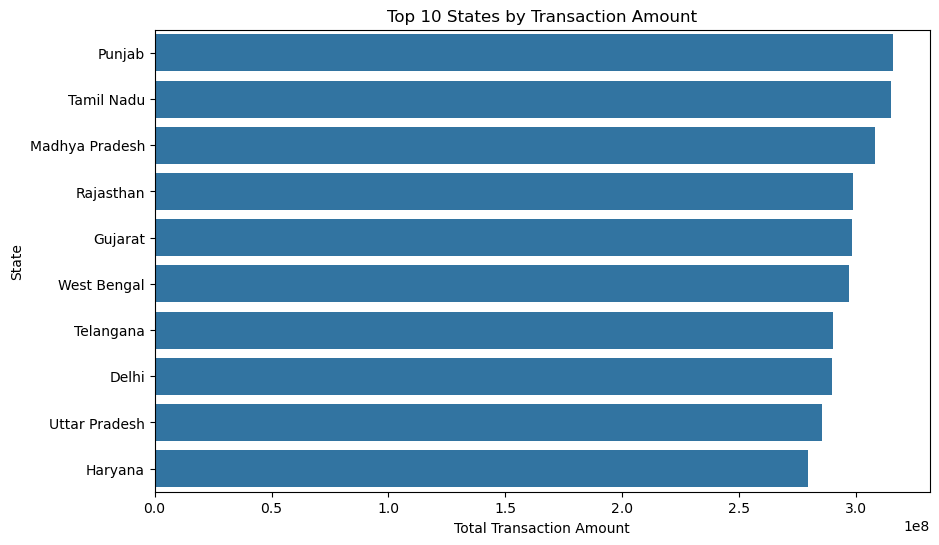

In [115]:
#Top States by Transaction Amount

top_states = (
    investor_transactions
    .groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.xlabel('Total Transaction Amount')
plt.ylabel('State')
plt.title('Top 10 States by Transaction Amount')

plt.show()

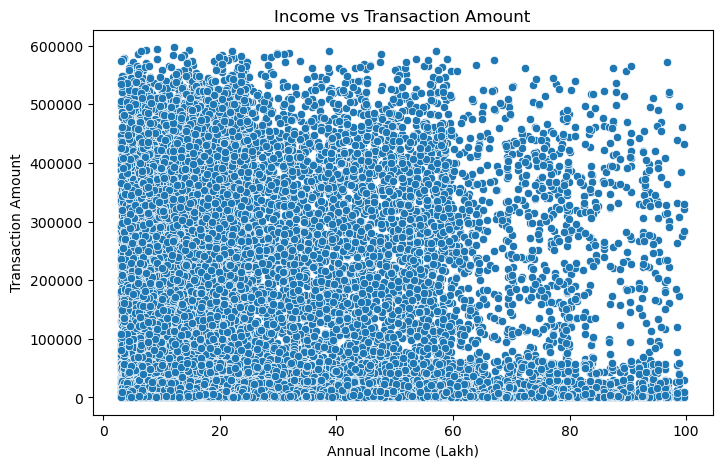

In [116]:
#Income Group vs Transaction Amount

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=investor_transactions,
    x='annual_income_lakh',
    y='amount_inr'
)

plt.xlabel('Annual Income (Lakh)')
plt.ylabel('Transaction Amount')
plt.title('Income vs Transaction Amount')

plt.show()

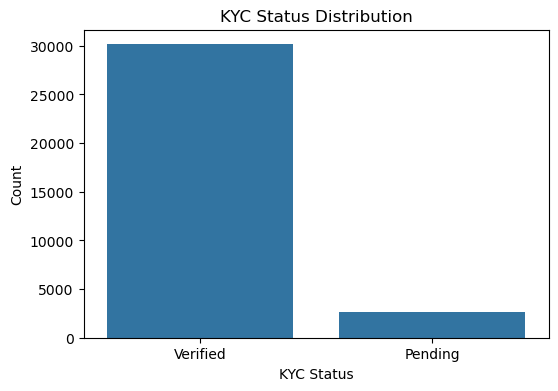

In [117]:
#KYC Status Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=investor_transactions,
    x='kyc_status'
)

plt.xlabel('KYC Status')
plt.ylabel('Count')
plt.title('KYC Status Distribution')

plt.show()

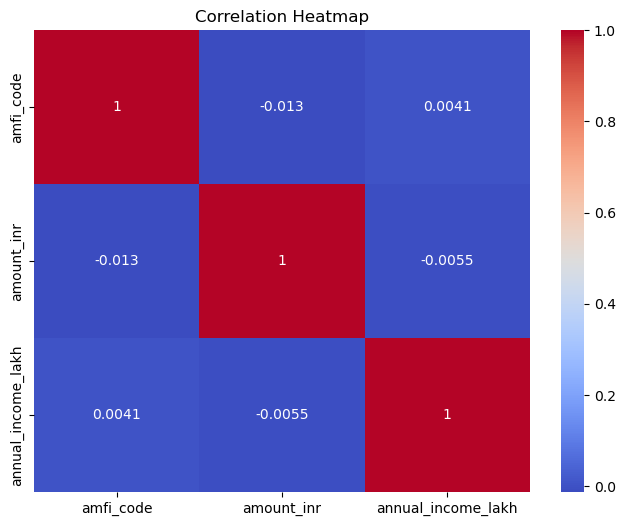

In [118]:
#Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    investor_transactions.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [119]:
query = "SELECT * FROM portfolio_holdings"

portfolio_holdings = pd.read_sql(query, engine)

portfolio_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [120]:
portfolio_holdings['portfolio_date'] = pd.to_datetime(
    portfolio_holdings['portfolio_date']
)

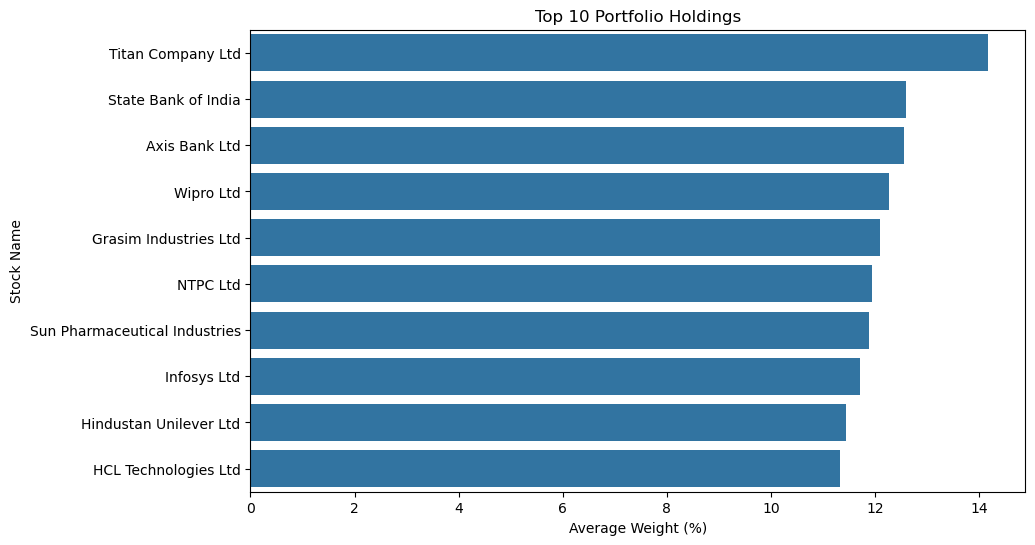

In [121]:
#Top 10 Stocks by Average Weight

top_holdings = (
    portfolio_holdings
    .groupby('stock_name')['weight_pct']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_holdings.values,
    y=top_holdings.index
)

plt.xlabel('Average Weight (%)')
plt.ylabel('Stock Name')
plt.title('Top 10 Portfolio Holdings')

plt.show()

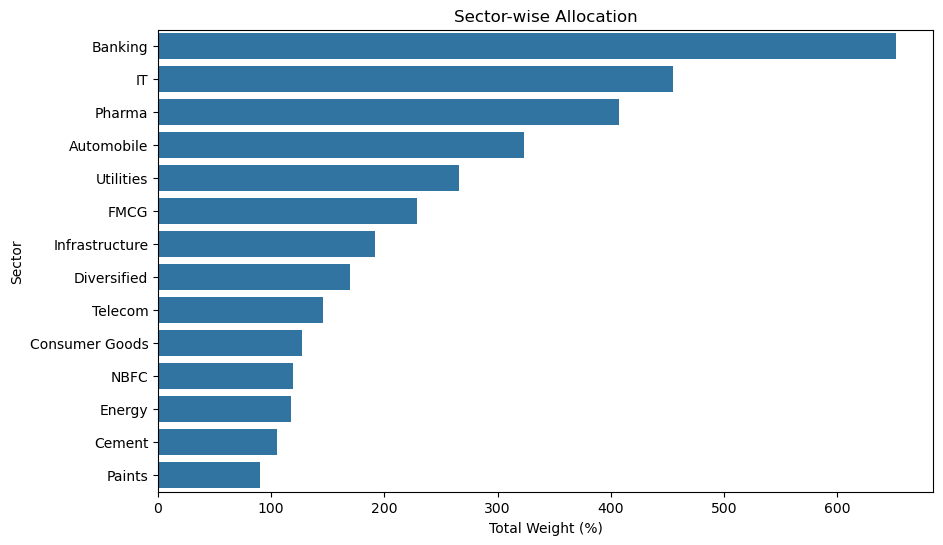

In [122]:
#Sector-wise Allocation

sector_weights = (
    portfolio_holdings
    .groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=sector_weights.values,
    y=sector_weights.index
)

plt.xlabel('Total Weight (%)')
plt.ylabel('Sector')
plt.title('Sector-wise Allocation')

plt.show()

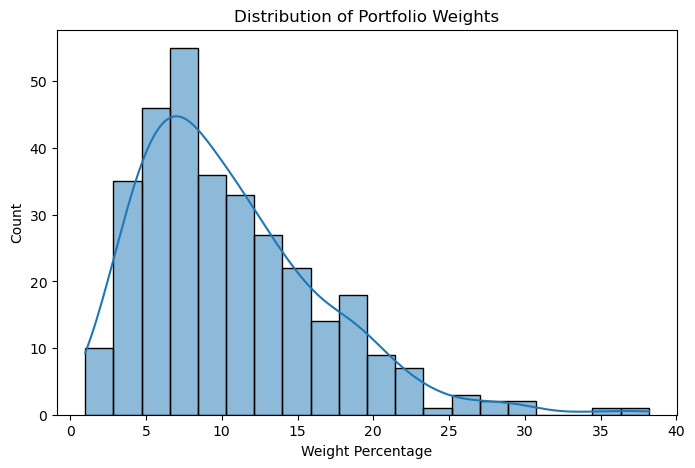

In [123]:
#Distribution of Weight Percentage

plt.figure(figsize=(8,5))

sns.histplot(
    portfolio_holdings['weight_pct'],
    bins=20,
    kde=True
)

plt.xlabel('Weight Percentage')
plt.title('Distribution of Portfolio Weights')

plt.show()

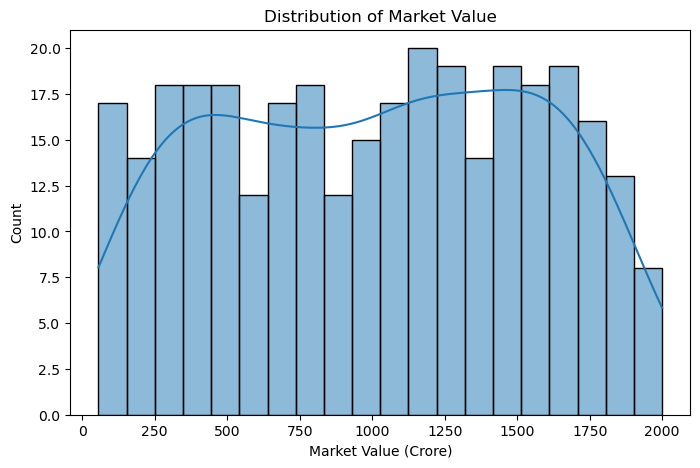

In [124]:
#Market Value Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    portfolio_holdings['market_value_cr'],
    bins=20,
    kde=True
)

plt.xlabel('Market Value (Crore)')
plt.title('Distribution of Market Value')

plt.show()

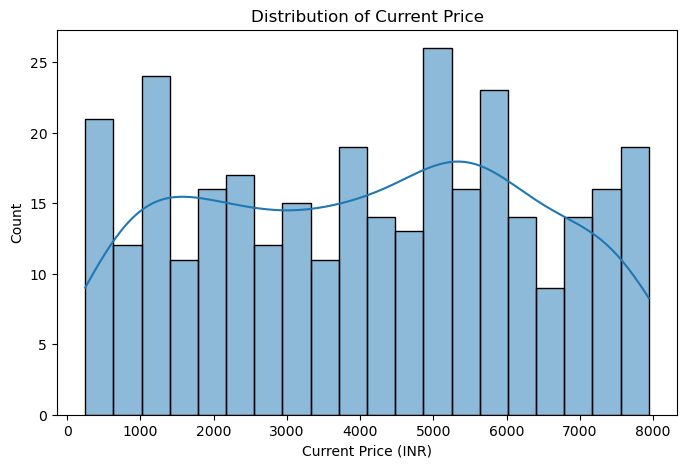

In [125]:
#Current Price Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    portfolio_holdings['current_price_inr'],
    bins=20,
    kde=True
)

plt.xlabel('Current Price (INR)')
plt.title('Distribution of Current Price')

plt.show()

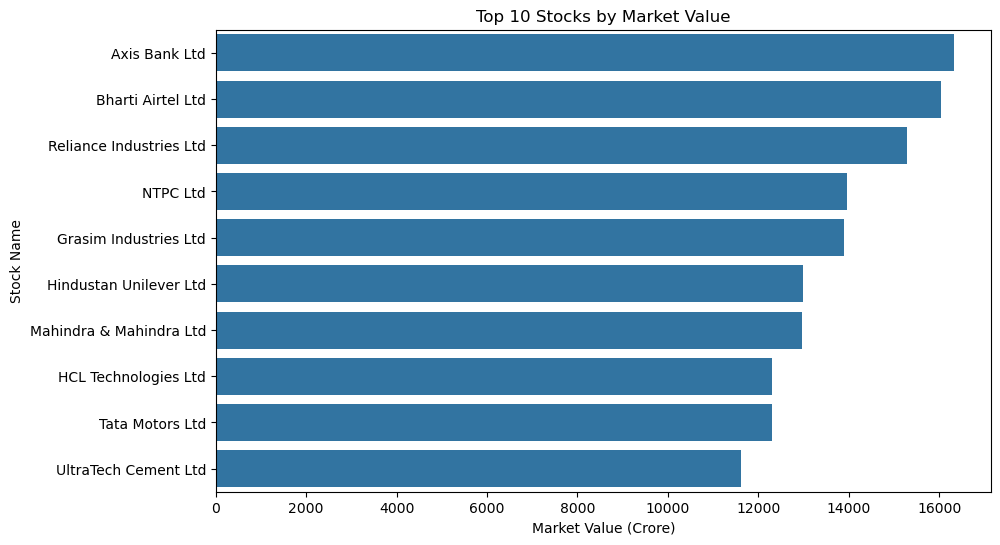

In [126]:
#Top 10 Stocks by Market Value

top_market_value = (
    portfolio_holdings
    .groupby('stock_name')['market_value_cr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_market_value.values,
    y=top_market_value.index
)

plt.xlabel('Market Value (Crore)')
plt.ylabel('Stock Name')
plt.title('Top 10 Stocks by Market Value')

plt.show()

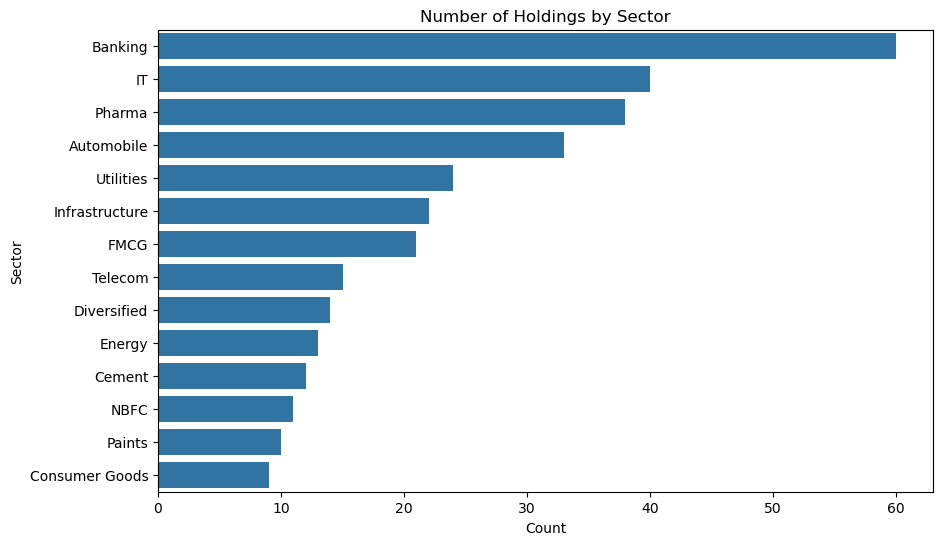

In [127]:
#Sector-wise Number of Stocks

plt.figure(figsize=(10,6))

sns.countplot(
    data=portfolio_holdings,
    y='sector',
    order=portfolio_holdings['sector'].value_counts().index
)

plt.xlabel('Count')
plt.ylabel('Sector')
plt.title('Number of Holdings by Sector')

plt.show()

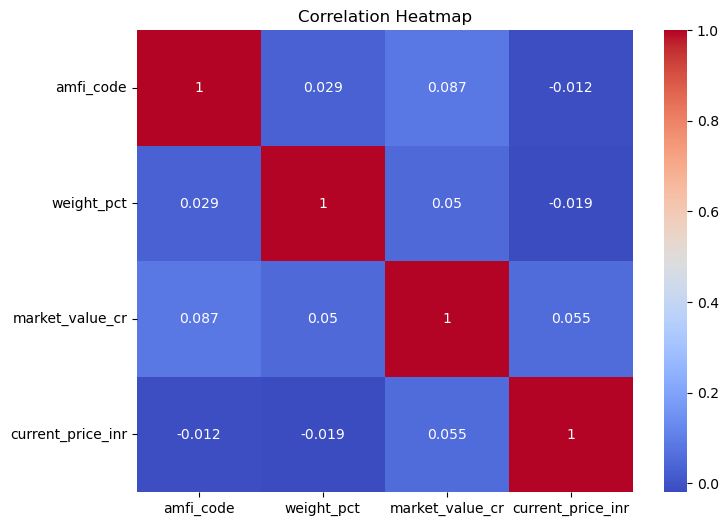

In [128]:
#Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    portfolio_holdings.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [129]:
query = "SELECT * FROM benchmark_indices"

benchmark_indices = pd.read_sql(query, engine)

benchmark_indices.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [130]:
benchmark_indices['date'] = pd.to_datetime(
    benchmark_indices['date']
)

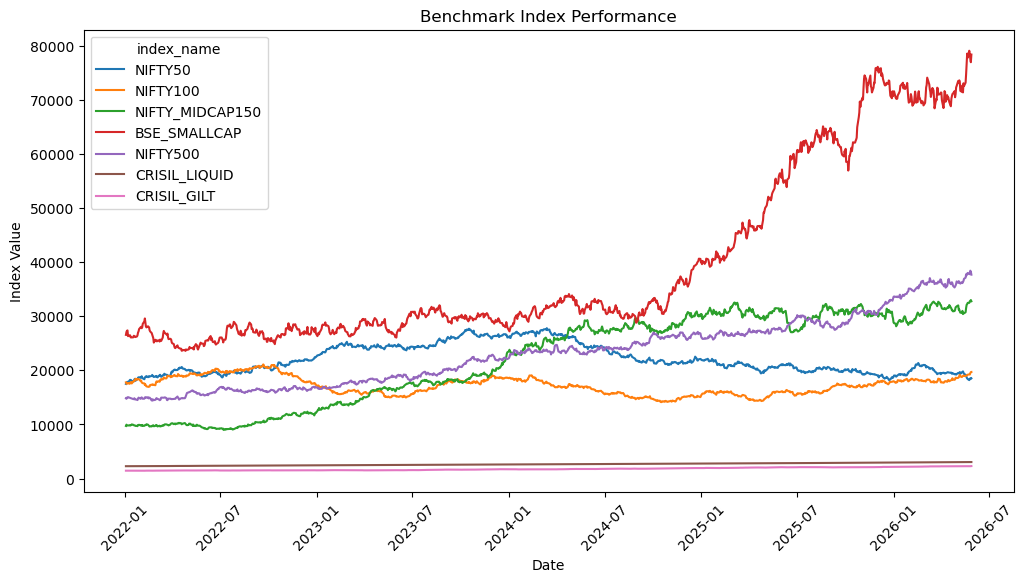

In [131]:
#Benchmark Index Trend

plt.figure(figsize=(12,6))

sns.lineplot(
    data=benchmark_indices,
    x='date',
    y='close_value',
    hue='index_name'
)

plt.xlabel('Date')
plt.ylabel('Index Value')
plt.title('Benchmark Index Performance')

plt.xticks(rotation=45)

plt.show()

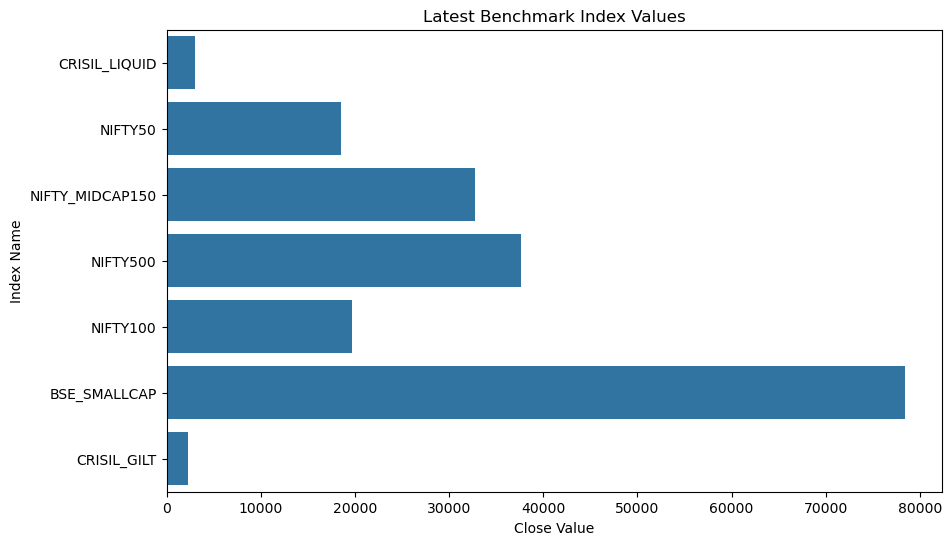

In [132]:
#Latest Index Values

latest_index = (
    benchmark_indices
    .sort_values('date')
    .groupby('index_name')
    .tail(1)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=latest_index,
    x='close_value',
    y='index_name'
)

plt.xlabel('Close Value')
plt.ylabel('Index Name')
plt.title('Latest Benchmark Index Values')

plt.show()

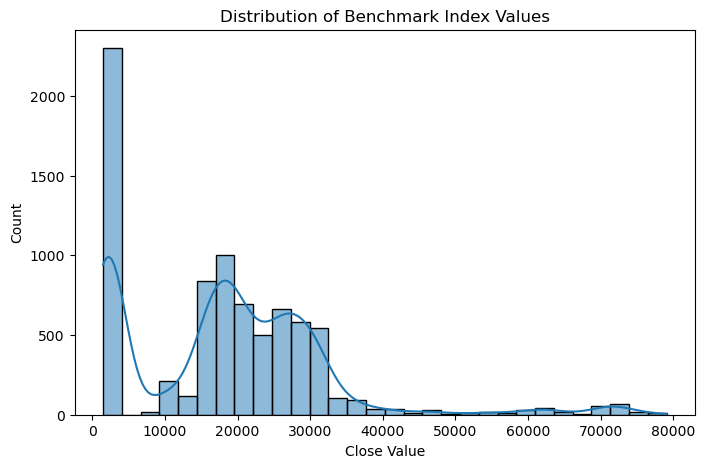

In [133]:
#Distribution of Index Values

plt.figure(figsize=(8,5))

sns.histplot(
    benchmark_indices['close_value'],
    bins=30,
    kde=True
)

plt.xlabel('Close Value')
plt.title('Distribution of Benchmark Index Values')

plt.show()

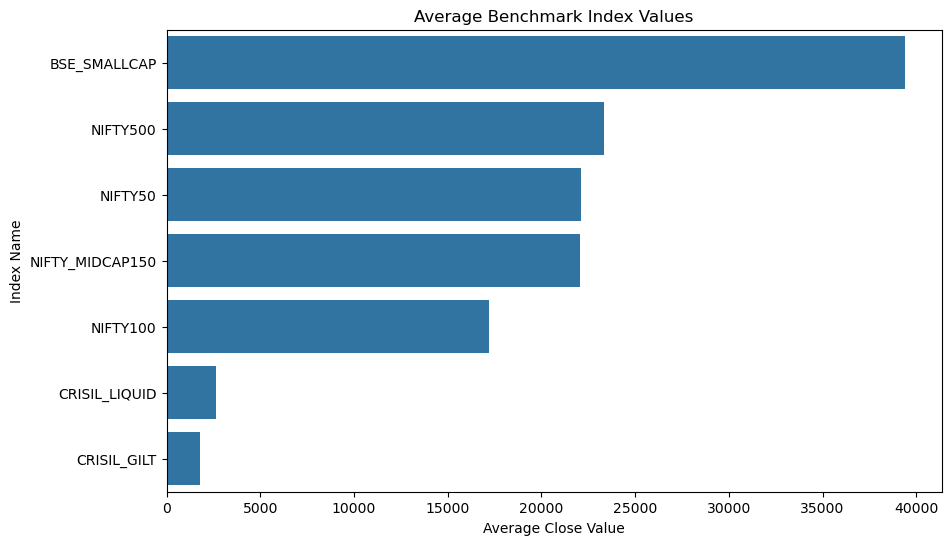

In [134]:
#Average Value by Index

avg_index = (
    benchmark_indices
    .groupby('index_name')['close_value']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_index.values,
    y=avg_index.index
)

plt.xlabel('Average Close Value')
plt.ylabel('Index Name')
plt.title('Average Benchmark Index Values')

plt.show()

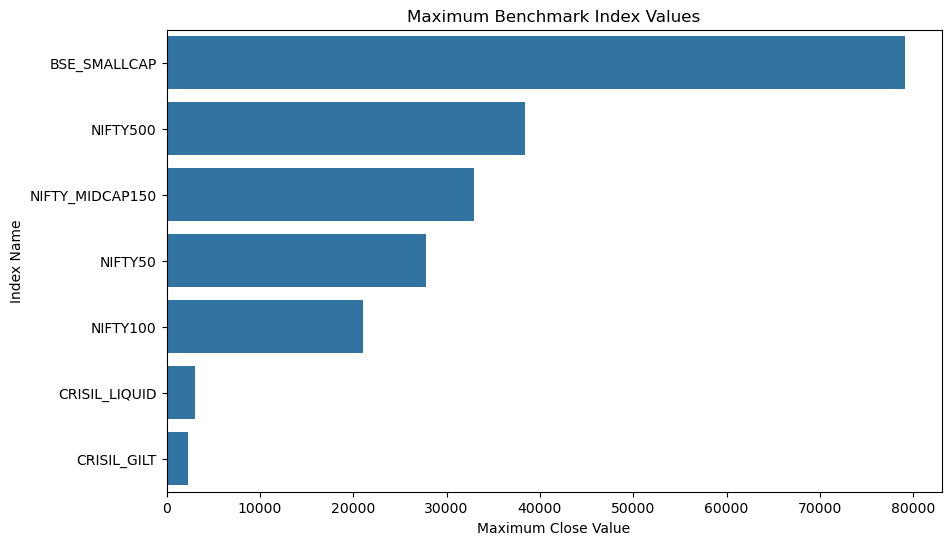

In [135]:
#Maximum Value by Index

max_index = (
    benchmark_indices
    .groupby('index_name')['close_value']
    .max()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=max_index.values,
    y=max_index.index
)

plt.xlabel('Maximum Close Value')
plt.ylabel('Index Name')
plt.title('Maximum Benchmark Index Values')

plt.show()

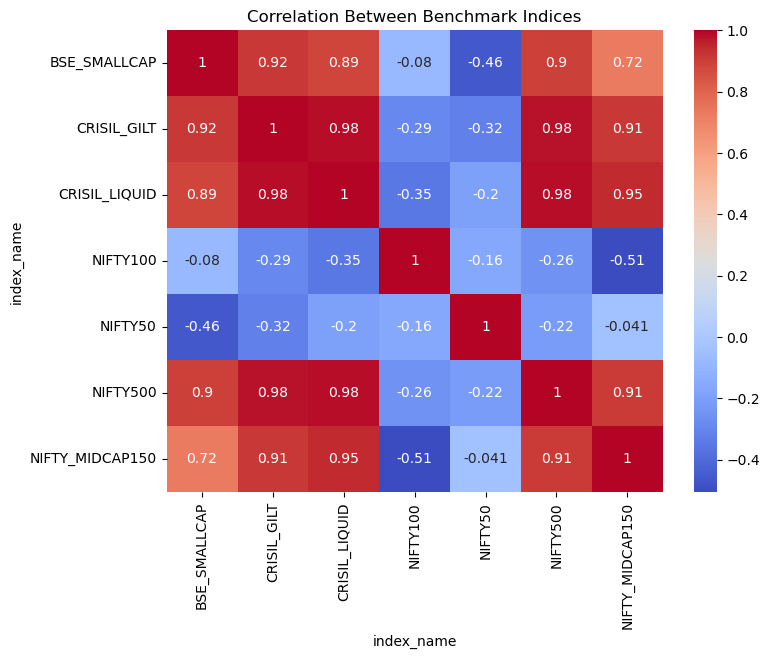

In [136]:
#Correlation Heatmap

benchmark_pivot = benchmark_indices.pivot(
    index='date',
    columns='index_name',
    values='close_value'
)

plt.figure(figsize=(8,6))

sns.heatmap(
    benchmark_pivot.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Benchmark Indices')

plt.show()

In [ ]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="swapnil@123",
    host="127.0.0.1",
    port=5432,
    database="bluestock_mf"
)

engine = create_engine(url)